# Código del TFM — Predicción de la accesibilidad a la vivienda en España

**Autor:** Marcos Rodrigo Bermejo Arroyo  
**Máster:** Big Data, Data Science & Artificial Intelligence  
**Curso académico:** 2025/26

La numeración de los apartados coincide con la de la memoria, de modo que
cada resultado citado en el texto puede localizarse en la celda
correspondiente.

El conjunto de datos empleado, el código que lo construye a partir de las
fuentes oficiales y su auditoría se encuentran disponibles en
[github.com/rodridemarcos/TFM_MRBA](https://github.com/rodridemarcos/TFM_MRBA).

## 0. Configuración del entorno

Se cargan las librerías empleadas a lo largo del cuaderno, se fija la
semilla que garantiza la reproducibilidad de los resultados y se establece
el formato de presentación de las tablas. Todos los valores numéricos se
muestran con tres decimales.

In [1]:
# ============================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GENERAL
# ============================================================

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    ElasticNet,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline
import joblib
from pathlib import Path


# ============================================================
# PARÁMETROS GLOBALES DEL ESTUDIO
# ============================================================

SEMILLA = 42                    # Reproducibilidad de los procesos aleatorios
HORIZONTE = 4                   # Trimestres de antelación de la predicción
SUPERFICIE_REFERENCIA_M2 = 80   # Vivienda tipo del cálculo del IAV
ANIO_BASE = 2015                # Año de anclaje del nivel de precios
DECIMALES = 3                   # Decimales mostrados en tablas y figuras
np.random.seed(SEMILLA)
warnings.filterwarnings("ignore", category=FutureWarning)


# ============================================================
# CONFIGURACIÓN DE VISUALIZACIÓN
# ============================================================

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 150)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.{DECIMALES}f}",
)

sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "font.size": 10,
})

print(
    f"Entorno configurado. "
    f"Semilla: {SEMILLA} | "
    f"Horizonte: {HORIZONTE} trimestres"
)

Entorno configurado. Semilla: 42 | Horizonte: 4 trimestres


### 1. Funciones auxiliares

La evaluación de modelos y la presentación de resultados se repiten en
prácticamente todos los apartados del cuaderno. Concentrar estas
operaciones en unas pocas funciones evita la duplicación de código y
garantiza que todas las comparaciones se realizan exactamente de la misma
forma.

Junto a las métricas habituales se incorporan tres herramientas de
diagnóstico que se emplearán en la comparación final del capítulo 4:

- **Skill score:** reducción porcentual del error respecto a la referencia
  de persistencia. Un valor positivo indica mejora.
- **$R^2$ intraprovincial:** coeficiente de determinación calculado tras
  eliminar el nivel medio de cada territorio. Resulta necesario porque, en
  un panel provincial, el $R^2$ convencional queda dominado por las
  diferencias estructurales entre provincias y sobrestima la calidad del
  ajuste.
- **Contraste de Diebold y Mariano:** determina si la diferencia de error
  entre dos métodos es estadísticamente significativa o atribuible al
  azar. Se aplica la corrección de Harvey, Leybourne y Newbold para
  muestras reducidas y una varianza de largo plazo con tres retardos,
  coherente con el horizonte de cuatro trimestres.

In [2]:
# ============================================================
# 1. FUNCIONES AUXILIARES DE PRESENTACIÓN
# ============================================================

def tabla(datos, columnas=("Indicador", "Valor")):
    """Convierte un diccionario en una tabla de dos columnas."""
    return pd.DataFrame(
        list(datos.items()),
        columns=list(columnas),
    )


def figura(titulo, xlabel="", ylabel="", figsize=(10, 5)):
    """Crea una figura con el formato homogéneo de la memoria."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return fig, ax


def controlar(comprobaciones):
    """Muestra los controles de integridad e interrumpe si falla alguno.

    Solo se incluyen aquí las condiciones que sustentan afirmaciones de
    la memoria y cuyo resultado no es visible en ninguna otra tabla.
    """
    resultado = tabla(
        {
            nombre: ("Correcto" if cumple else "INCUMPLIDO")
            for nombre, cumple in comprobaciones.items()
        },
        columnas=("Control", "Resultado"),
    )

    incumplidos = [
        nombre
        for nombre, cumple in comprobaciones.items()
        if not cumple
    ]

    assert not incumplidos, (
        f"Controles incumplidos: {incumplidos}"
    )

    return resultado


# ============================================================
# 2. MÉTRICAS DE ERROR Y REGISTRO DE RESULTADOS
# ============================================================

def calcular_metricas(y_real, y_predicho):
    """Devuelve MAE, RMSE, MAPE (en porcentaje) y R2."""
    y_real = np.asarray(y_real, dtype=float).ravel()
    y_predicho = np.asarray(y_predicho, dtype=float).ravel()

    return {
        "MAE": mean_absolute_error(y_real, y_predicho),
        "RMSE": np.sqrt(
            mean_squared_error(y_real, y_predicho)
        ),
        "MAPE": mean_absolute_percentage_error(
            y_real, y_predicho
        ) * 100,
        "R2": r2_score(y_real, y_predicho),
    }


def registrar(estrategia, modelo, conjunto, y_real, y_predicho, **extra):
    """Construye una fila de resultados con estructura homogénea."""
    fila = {
        "Estrategia": estrategia,
        "Modelo": modelo,
        "Conjunto": conjunto,
    }
    fila.update(calcular_metricas(y_real, y_predicho))
    fila.update(extra)
    return fila


def comparar_con_referencia(resultados, mae_referencia):
    """Añade el skill score frente a la referencia de persistencia.

    Un valor positivo indica que el modelo reduce el error de la
    referencia y uno negativo, que lo empeora.
    """
    resultados = (
        resultados
        .sort_values("MAE")
        .reset_index(drop=True)
    )

    resultados["Skill score (%)"] = (
        (mae_referencia - resultados["MAE"])
        / mae_referencia
        * 100
    )

    return resultados


# ============================================================
# 3. DIAGNÓSTICO AVANZADO DE LAS PREDICCIONES
# ============================================================

def r2_intraprovincial(y_real, y_predicho, provincias):
    """R2 calculado tras eliminar el nivel medio de cada territorio.

    Mide la capacidad del modelo para anticipar la evolución dentro de
    cada provincia, sin beneficiarse de las diferencias de nivel entre
    territorios.
    """
    datos = pd.DataFrame({
        "real": np.ravel(y_real),
        "predicho": np.ravel(y_predicho),
        "provincia": np.ravel(provincias),
    })

    medias = (
        datos
        .groupby("provincia")["real"]
        .transform("mean")
    )

    return r2_score(
        datos["real"] - medias,
        datos["predicho"] - medias,
    )


def test_diebold_mariano(errores_a, errores_b, horizonte=HORIZONTE):
    """Contrasta si dos métodos de predicción difieren en precisión.

    La hipótesis nula establece que ambos poseen el mismo error
    esperado. Un estadístico negativo indica que el primer método
    comete menos error que el segundo.
    """
    diferencia = (
        np.abs(np.ravel(errores_a))
        - np.abs(np.ravel(errores_b))
    )

    n = len(diferencia)
    media = diferencia.mean()

    # Varianza de largo plazo de Newey-West con horizonte - 1 retardos.
    varianza = np.mean((diferencia - media) ** 2)

    for retardo in range(1, horizonte):
        autocovarianza = np.mean(
            (diferencia[retardo:] - media)
            * (diferencia[:-retardo] - media)
        )
        varianza += (
            2 * (1 - retardo / horizonte) * autocovarianza
        )

    # Corrección de Harvey, Leybourne y Newbold (1997).
    factor = np.sqrt(
        (
            n + 1
            - 2 * horizonte
            + horizonte * (horizonte - 1) / n
        ) / n
    )

    estadistico = (
        media / np.sqrt(max(varianza, 1e-12) / n) * factor
    )

    p_valor = 2 * (
        1 - stats.t.cdf(abs(estadistico), df=n - 1)
    )

    return {
        "Diferencia media de error": media,
        "Estadístico DM": estadistico,
        "p-valor": p_valor,
        "Significativo al 5%": p_valor < 0.05,
    }


def describir_numericas(datos, columnas):
    """Resumen descriptivo con asimetría, curtosis y valores atípicos.

    Los atípicos se identifican mediante el criterio del rango
    intercuartílico, considerando extremos los situados a más de 1,5
    rangos de los cuartiles primero y tercero.
    """
    resumen = (
        datos[columnas]
        .describe()
        .T
        .drop(columns="count")
    )

    q1 = datos[columnas].quantile(0.25)
    q3 = datos[columnas].quantile(0.75)
    rango = q3 - q1

    atipicos = (
        (datos[columnas] < q1 - 1.5 * rango)
        | (datos[columnas] > q3 + 1.5 * rango)
    ).sum()

    resumen["asimetria"] = datos[columnas].skew()
    resumen["curtosis"] = datos[columnas].kurtosis()
    resumen["atipicos_pct"] = atipicos / len(datos) * 100

    return resumen


print("Funciones auxiliares definidas correctamente.")

Funciones auxiliares definidas correctamente.


## 2. Construcción y análisis exploratorio del *dataset*

### 2.1. Fuentes, unidad de análisis y cobertura

Se carga el conjunto definitivo junto con su auditoría, generados ambos
por el script `construir_dataset_TFM_MRBA.py` a partir de las fuentes
oficiales del Instituto Nacional de Estadística, la Agencia Estatal de
Administración Tributaria, el Banco de España y el Ministerio de Vivienda
y Agenda Urbana.

La unidad de análisis es la combinación de un territorio y un trimestre,
por lo que resulta imprescindible verificar que cada par provincia-periodo
aparece una sola vez y que ningún territorio presenta trimestres ausentes.
De no cumplirse esta condición, el panel estaría desequilibrado y las
comparaciones territoriales quedarían distorsionadas.

In [3]:
# ============================================================
# 4. CARGA DEL DATASET Y DE SU AUDITORÍA
# ============================================================

URL_BASE = (
    "https://raw.githubusercontent.com/rodridemarcos/TFM_MRBA/"
    "refs/heads/main/construcci%C3%B3n_dataset/"
)

df = pd.read_csv(
    URL_BASE + "dataset_TFM_MRBA.csv",
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
)

auditoria = pd.read_csv(
    URL_BASE + "auditoria_dataset_TFM_MRBA.csv",
    sep=";",
    encoding="utf-8-sig",
)

df.columns = df.columns.str.strip()

print("Dataset cargado correctamente desde GitHub.")
print(
    f"Dimensiones: {df.shape[0]:,} filas "
    f"× {df.shape[1]} columnas"
)
display(df.head())


# ============================================================
# 5. PAPEL DE CADA VARIABLE
# ============================================================

# La auditoría documenta el bloque temático, el nivel de
# desagregación territorial y el uso admisible de cada variable.

IDENTIFICADORES = auditoria.loc[
    auditoria["Clasificación"] == "Identificadores",
    "Variable",
].tolist()

OBJETIVO = "IAV_total"

# Las variables derivadas del objetivo no pueden actuar como
# predictoras, ya que introducirían fuga de información.
NO_PREDICTORAS = auditoria.loc[
    auditoria["Uso"] == "No predictora",
    "Variable",
].tolist()

PREDICTORAS_CANDIDATAS = [
    columna
    for columna in df.columns
    if columna not in IDENTIFICADORES + NO_PREDICTORAS
    and columna != "valores_arrastrados"
]


# ============================================================
# 6. DESCOMPOSICIÓN DEL IDENTIFICADOR TEMPORAL
# ============================================================

# Se separan el año y el trimestre de valores como "2015T1".
partes = df["periodo"].str.extract(
    r"^(?P<anio>\d{4})T(?P<trimestre>[1-4])$"
)

df["anio"] = partes["anio"].astype(int)
df["trimestre"] = partes["trimestre"].astype(int)
df["orden_periodo"] = df["anio"] * 10 + df["trimestre"]

periodos = (
    df
    .sort_values("orden_periodo")["periodo"]
    .unique()
    .tolist()
)

provincias = sorted(df["provincia"].unique())


# ============================================================
# 7. COMPROBACIÓN DE LA COBERTURA DEL PANEL
# ============================================================

# Se construye la combinación teórica de todas las provincias y
# todos los periodos para compararla con el dataset observado.

indice_esperado = pd.MultiIndex.from_product(
    [provincias, periodos]
)

indice_observado = pd.MultiIndex.from_frame(
    df[["provincia", "periodo"]]
)

combinaciones_ausentes = len(
    indice_esperado.difference(indice_observado)
)

display(tabla({
    "Observaciones": len(df),
    "Variables del dataset": df.shape[1] - 3,
    "Predictoras candidatas": len(PREDICTORAS_CANDIDATAS),
    "Territorios": df["provincia"].nunique(),
    "Comunidades autónomas": df["comunidad_autonoma"].nunique(),
    "Trimestres": df["periodo"].nunique(),
    "Cobertura temporal": f"{periodos[0]} - {periodos[-1]}",
    "Filas duplicadas": int(df.duplicated().sum()),
    "Duplicados provincia-periodo": int(
        df.duplicated(
            subset=["provincia", "periodo"]
        ).sum()
    ),
    "Valores ausentes": int(df.isna().sum().sum()),
    "Combinaciones provincia-periodo vacías": (
        combinaciones_ausentes
    ),
}))

Dataset cargado correctamente desde GitHub.
Dimensiones: 2,080 filas × 37 columnas


,periodo,codigo_provincia,provincia,comunidad_autonoma,poblacion_total,pct_18_34,pct_35_64,pct_65_mas,tamano_medio_hogar,pct_hogares_unipersonales,pct_poblacion_espanola,tasa_migracion_neta_exterior_por_1000_habitantes,salario_medio_anual_euros_total,salario_medio_anual_euros_hombre,salario_medio_anual_euros_mujer,tasa_actividad_pct_total,tasa_empleo_pct_total,tasa_paro_pct_total,renta_neta_media_por_hogar_eur,renta_mediana_por_unidad_consumo_eur,indice_precios_consumo_base_2015,indice_costes_construccion,tipo_interes_prestamos_vivienda_pct,importe_medio_hipoteca_vivienda_eur,valor_tasado_m2,ipv_general,compraventas_por_1000_hab,pct_compraventas_vivienda_nueva,visados_obra_nueva_por_1000_hab,plazas_hoteleras_por_1000_hab,pernoctaciones_por_habitante,valores_arrastrados,precio_m2_mercado,IAV_hombre,IAV_mujer,brecha_iav_absoluta,IAV_total
0,2015T1,2,Albacete,Castilla - La Mancha,"394,012.000",20.914,39.530,21.496,2.600,27.700,93.900,-0.540,"15,728.000","16,985.000","14,033.000",57.210,40.720,28.820,"24,100.000","11,550.000",98.960,90.330,2.613,"82,770.640",959.500,69.067,1.383,26.240,0.188,14.600,0.260,0,945.800,4.455,5.392,0.937,4.811
1,2015T2,2,Albacete,Castilla - La Mancha,"394,012.000",20.914,39.530,21.496,2.600,27.700,93.900,-0.540,"15,728.000","16,985.000","14,033.000",58.190,43.840,24.660,"24,100.000","11,550.000",100.890,93.720,2.507,"78,629.410",969.700,70.506,1.167,26.300,0.297,16.858,0.425,0,965.506,4.548,5.504,0.957,4.911
2,2015T3,2,Albacete,Castilla - La Mancha,"394,012.000",20.914,39.530,21.496,2.600,27.700,93.900,-0.540,"15,728.000","16,985.000","14,033.000",57.720,44.280,23.280,"24,100.000","11,550.000",99.690,90.260,2.450,"78,082.220",945.300,70.161,1.221,21.210,0.338,16.686,0.475,0,960.782,4.525,5.477,0.952,4.887
3,2015T4,2,Albacete,Castilla - La Mancha,"394,012.000",20.914,39.530,21.496,2.600,27.700,93.900,-0.540,"15,728.000","16,985.000","14,033.000",58.070,45.320,21.970,"24,100.000","11,550.000",100.460,92.907,2.427,"86,327.870",961.300,70.375,1.223,22.410,0.802,15.371,0.409,0,963.712,4.539,5.494,0.955,4.902
4,2016T1,2,Albacete,Castilla - La Mancha,"391,865.000",20.304,39.860,21.898,2.600,28.200,94.100,0.830,"15,780.000","17,082.000","14,046.000",56.190,42.330,24.670,"24,785.000","12,250.000",97.910,88.550,2.330,"87,970.460",953.300,70.088,1.442,20.000,0.276,14.024,0.281,0,959.782,4.495,5.467,0.972,4.866


,Indicador,Valor
0,Observaciones,2080
1,Variables del dataset,37
2,Predictoras candidatas,25
3,Territorios,52
4,Comunidades autónomas,19
5,Trimestres,40
6,Cobertura temporal,2015T1 - 2024T4
7,Filas duplicadas,0
8,Duplicados provincia-periodo,0
9,Valores ausentes,0


El conjunto contiene 2.080 observaciones y 37 variables, y cada uno de los
52 territorios dispone de información para los 40 trimestres comprendidos
entre 2015T1 y 2024T4. No se detectan duplicados, valores ausentes ni
combinaciones provincia-periodo vacías, por lo que el conjunto constituye
un **panel equilibrado**. Esta propiedad permitirá más adelante desplazar
la variable objetivo cuatro trimestres dentro de cada provincia sin
introducir huecos irregulares.

De las 37 variables, 25 actúan como predictoras candidatas. La
denominación *candidatas* es intencionada, ya que su inclusión definitiva
dependerá de la disponibilidad temporal, la redundancia y la aportación
predictiva que se evalúan en el capítulo 3.

Siete variables quedan excluidas de antemano por derivar de la variable
objetivo: el precio de mercado reconstruido, los salarios masculino y
femenino, el IAV calculado con cada uno de ellos, la brecha resultante y
el propio indicador. Emplearlas como predictoras equivaldría a introducir
el valor que se pretende anticipar. Se conservan no obstante en el
conjunto porque sustentan el análisis descriptivo de este capítulo y la
aplicación desarrollada en el capítulo 6.

### 2.2. Definición y reconstrucción del IAV

El Índice de Accesibilidad a la Vivienda representa los años de salario
bruto medio anual necesarios para adquirir una vivienda de referencia de
80 m²:

$$IAV_{p,t} = \frac{80 \times \text{precio del m}^2_{p,t}}{\text{salario bruto medio anual}_{p,t}}$$

El indicador es un cociente entre dos magnitudes nominales, de modo que la
inflación se cancela por construcción y no procede aplicar ningún ajuste
adicional de precios sobre el numerador.

La determinación del numerador exige una decisión metodológica. El valor
tasado publicado por el Ministerio subestima de forma sistemática la
evolución del mercado, ya que las tasaciones se apoyan en operaciones
comparables anteriores y responden con retraso: entre 2015 y 2024 crece un
18,8%, frente al 51,1% del Índice de Precios de Vivienda del INE.

Se combinan por tanto ambas fuentes según su fortaleza respectiva. El
valor tasado aporta el **nivel** provincial de 2015, fiable para comparar
territorios entre sí, y el IPV aporta la **evolución**, que es la magnitud
oficial de referencia:

$$\text{precio m}^2_{p,t} = \text{valor tasado}_{p,2015} \times \frac{IPV_{p,t}}{IPV_{p,2015}}$$

La limitación de este procedimiento debe hacerse explícita: el IPV se
publica por comunidad autónoma, por lo que las provincias de una misma
comunidad comparten tasa de variación, aunque conservan niveles distintos.

In [4]:
# ============================================================
# 8. COMPROBACIÓN DE LA FÓRMULA DEL IAV
# ============================================================

#                     80 × precio del m²
# IAV total = ------------------------------------
#                 salario bruto medio anual

iav_recalculado = (
    SUPERFICIE_REFERENCIA_M2 * df["precio_m2_mercado"]
    / df["salario_medio_anual_euros_total"]
)

discrepancias = int(
    (
        (iav_recalculado - df[OBJETIVO]).abs() > 0.005
    ).sum()
)

coste_vivienda = (
    SUPERFICIE_REFERENCIA_M2 * df["precio_m2_mercado"]
)


# ============================================================
# 9. CONTRASTE ENTRE EL PRECIO RECONSTRUIDO Y EL TASADO
# ============================================================

# Se compara la evolución de ambas series con base 2015 = 100
# para cuantificar el desfase que corrige la reconstrucción.

evolucion_precios = (
    df
    .groupby("anio")[["valor_tasado_m2", "precio_m2_mercado"]]
    .mean()
)

indice_precios = (
    evolucion_precios
    / evolucion_precios.loc[ANIO_BASE]
    * 100
).round(1)

indice_precios.columns = [
    "Valor tasado (2015 = 100)",
    "Precio reconstruido (2015 = 100)",
]

display(indice_precios)


# ============================================================
# 10. ESCALA Y PERIODICIDAD DEL INDICADOR
# ============================================================

# El salario se publica con frecuencia anual y se asigna a los
# cuatro trimestres del año, mientras que el precio varía cada
# trimestre. Se verifica sobre las 520 combinaciones de
# provincia y año.

periodicidad = (
    df
    .groupby(["provincia", "anio"])
    .agg(
        salarios=(
            "salario_medio_anual_euros_total",
            "nunique",
        ),
        precios=("precio_m2_mercado", "nunique"),
    )
)

display(tabla({
    "Discrepancias con la fórmula": discrepancias,
    "IAV medio (años de salario)": round(
        df[OBJETIVO].mean(), DECIMALES
    ),
    "IAV mediano": round(df[OBJETIVO].median(), DECIMALES),
    "Recorrido del IAV": (
        f"{df[OBJETIVO].min():.2f} - "
        f"{df[OBJETIVO].max():.2f}"
    ),
    "Coste medio de la vivienda de referencia (€)": round(
        coste_vivienda.mean(), 2
    ),
    "Recorrido del coste (€)": (
        f"{coste_vivienda.min():,.0f} - "
        f"{coste_vivienda.max():,.0f}"
    ),
    "Provincia-año con salario constante": (
        f"{int((periodicidad['salarios'] == 1).sum())} "
        f"de {len(periodicidad)}"
    ),
    "Provincia-año con precio variable": (
        f"{int((periodicidad['precios'] > 1).sum())} "
        f"de {len(periodicidad)}"
    ),
}))

,Valor tasado (2015 = 100),Precio reconstruido (2015 = 100)
anio,,
2015,100.000,100.000
2016,100.400,103.000
2017,101.300,107.000
2018,102.600,112.600
2019,104.500,118.000
2020,103.500,120.700
2021,105.200,125.300
2022,109.400,134.400
2023,113.100,139.500


,Indicador,Valor
0,Discrepancias con la fórmula,0
1,IAV medio (años de salario),5.835
2,IAV mediano,5.447
3,Recorrido del IAV,3.57 - 11.74
4,Coste medio de la vivienda de referencia (€),"119,314.680"
5,Recorrido del coste (€),"61,850 - 325,374"
6,Provincia-año con salario constante,520 de 520
7,Provincia-año con precio variable,520 de 520


El indicador reproduce la fórmula sin discrepancias. Su valor medio es de
5,835 años de salario, con una mediana de 5,447 y un recorrido comprendido
entre 3,57 y 11,74 años, lo que anticipa la elevada heterogeneidad
territorial analizada más adelante.

La tabla de índices cuantifica el efecto de la reconstrucción: mientras el
valor tasado alcanza 118,8 en 2024 con base 2015, el precio reconstruido
llega a 151,2. La diferencia de más de treinta puntos es la que separa la
evolución de las tasaciones de la del mercado, y explica que el indicador
calculado directamente sobre el valor tasado mostrase un descenso de la
dificultad de acceso, resultado incompatible con la evidencia disponible
sobre el periodo.

La comprobación de la periodicidad tiene además una consecuencia
metodológica relevante: al permanecer el salario constante dentro de cada
año, **toda la variación intranual del IAV procede exclusivamente del
precio de la vivienda**. Esta asimetría entre los dos componentes
justifica los distintos retardos de disponibilidad que se aplican en el
apartado 3.3 y explica por qué una referencia de persistencia construida
sobre el último precio conocido resulta tan competitiva.

### 2.3. Clasificación de las variables y calidad del conjunto

Las variables se organizan en seis bloques temáticos que se mantendrán
durante todo el trabajo, ya que constituyen la unidad sobre la que se
realiza el análisis de ablación del capítulo 5. La auditoría generada
junto al *dataset* documenta para cada una su bloque, descripción, unidad
y, sobre todo, su **nivel de desagregación territorial**.

Este último atributo merece atención particular. Una variable que toma un
único valor para toda España en cada trimestre no puede explicar por qué
un territorio resulta más o menos accesible que otro: solo aporta un
factor temporal común a las 52 provincias. Distinguirlas resulta por tanto
imprescindible para interpretar correctamente los resultados del
capítulo 5.

In [5]:
# ============================================================
# 11. CLASIFICACIÓN TEMÁTICA Y NIVEL DE DESAGREGACIÓN
# ============================================================

display(
    auditoria[[
        "Clasificación",
        "Variable",
        "Descripción",
        "Tipo de valor",
        "Nivel de desagregación",
        "Uso",
    ]]
)


# ============================================================
# 12. RESUMEN POR BLOQUE Y POR NIVEL TERRITORIAL
# ============================================================

predictoras = auditoria[
    auditoria["Variable"].isin(PREDICTORAS_CANDIDATAS)
]

display(
    predictoras
    .groupby("Clasificación", sort=False)
    .size()
    .rename("nº de predictoras")
    .to_frame()
)

display(
    predictoras["Nivel de desagregación"]
    .value_counts()
    .rename("nº de predictoras")
    .to_frame()
)

# Se identifican de forma explícita las series que no varían
# entre territorios, por su relevancia interpretativa.
for nivel in ["Nacional", "Autonómico"]:
    seleccion = predictoras.loc[
        predictoras["Nivel de desagregación"] == nivel,
        "Variable",
    ].tolist()
    print(f"{nivel}: {seleccion}")


# ============================================================
# 13. ETIQUETAS ABREVIADAS PARA TABLAS Y FIGURAS
# ============================================================

# Los nombres técnicos se conservan en el código. Estas
# etiquetas se emplean al representar resultados, ya que los
# nombres completos resultan ilegibles en las figuras.

ETIQUETAS = {
    "poblacion_total": "Población",
    "pct_18_34": "Población 18-34 años",
    "pct_35_64": "Población 35-64 años",
    "pct_65_mas": "Población 65+ años",
    "tamano_medio_hogar": "Tamaño del hogar",
    "pct_hogares_unipersonales": "Hogares unipersonales",
    "pct_poblacion_espanola": "Población española",
    "tasa_migracion_neta_exterior_por_1000_habitantes": (
        "Migración neta"
    ),
    "salario_medio_anual_euros_total": "Salario medio",
    "tasa_actividad_pct_total": "Tasa de actividad",
    "tasa_empleo_pct_total": "Tasa de empleo",
    "tasa_paro_pct_total": "Tasa de paro",
    "renta_neta_media_por_hogar_eur": "Renta por hogar",
    "renta_mediana_por_unidad_consumo_eur": (
        "Renta por unidad de consumo"
    ),
    "indice_precios_consumo_base_2015": "IPC (2015=100)",
    "indice_costes_construccion": "Costes de construcción",
    "tipo_interes_prestamos_vivienda_pct": "Tipo de interés",
    "importe_medio_hipoteca_vivienda_eur": "Hipoteca media",
    "valor_tasado_m2": "Valor tasado",
    "ipv_general": "IPV autonómico",
    "compraventas_por_1000_hab": "Compraventas",
    "pct_compraventas_vivienda_nueva": "Vivienda nueva",
    "visados_obra_nueva_por_1000_hab": "Visados de obra nueva",
    "plazas_hoteleras_por_1000_hab": "Plazas hoteleras",
    "pernoctaciones_por_habitante": "Pernoctaciones",
    "precio_m2_mercado": "Precio de mercado",
    "IAV_total": "IAV",
}

BLOQUES_TEMATICOS = {
    bloque: grupo["Variable"].tolist()
    for bloque, grupo in predictoras.groupby("Clasificación")
}

,Clasificación,Variable,Descripción,Tipo de valor,Nivel de desagregación,Uso
0,Identificadores,codigo_provincia,Código numérico del territorio,Entero,Identificador,Identificador
1,Identificadores,comunidad_autonoma,Comunidad autónoma,Categórico,Identificador,Identificador
2,Identificadores,periodo,Año y trimestre de la observación,Categórico,Identificador,Identificador
3,Identificadores,provincia,Provincia o ciudad autónoma,Categórico,Identificador,Identificador
4,Demografía y hogares,pct_18_34,Población de entre 18 y 34 años,%,Provincial,Predictora
5,Demografía y hogares,pct_35_64,Población de entre 35 y 64 años,%,Provincial,Predictora
6,Demografía y hogares,pct_65_mas,Población de 65 años o más,%,Provincial,Predictora
7,Demografía y hogares,pct_hogares_unipersonales,Proporción de hogares unipersonales,%,Provincial,Predictora
8,Demografía y hogares,pct_poblacion_espanola,Proporción de población de nacionalidad española,%,Provincial,Predictora
9,Demografía y hogares,poblacion_total,Población total del territorio,Entero,Provincial,Predictora


,nº de predictoras
Clasificación,
Demografía y hogares,8
Mercado laboral y rentas,6
Entorno económico,2
Financiación,2
Mercado residencial y oferta,5
Presión turística,2


,nº de predictoras
Nivel de desagregación,
Provincial,22
Nacional,2
Autonómico,1


Nacional: ['indice_costes_construccion', 'tipo_interes_prestamos_vivienda_pct']
Autonómico: ['ipv_general']


Las 25 predictoras se reparten en seis bloques: demografía y hogares (8),
mercado laboral y rentas (6), mercado residencial y oferta (5), entorno
económico (2), financiación (2) y presión turística (2).

El reparto por nivel territorial resulta más revelador: **22 predictoras
son provinciales, una autonómica y solo dos nacionales**. Las dos series
nacionales son el tipo de interés de los préstamos para vivienda y el
índice de costes de construcción, ambas publicadas por el Banco de España
y el Ministerio para el conjunto del país. La única serie autonómica es el
Índice de Precios de Vivienda, por la limitación de publicación ya
comentada.

Esta composición es una decisión deliberada de diseño. Las fuentes
disponibles ofrecían un número mucho mayor de indicadores agregados de
carácter financiero y macroeconómico, pero todos ellos comparten la misma
evolución temporal y resultan por tanto redundantes entre sí. Incorporarlos
de forma masiva llevaría al modelo a memorizar la trayectoria concreta del
periodo de entrenamiento en lugar de aprender las diferencias
estructurales entre territorios, que son las que permiten anticipar el
comportamiento de cada provincia.

In [6]:
# ============================================================
# 14. CONTROLES DE CALIDAD Y COHERENCIA
# ============================================================

numericas = (
    df[list(auditoria["Variable"])]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

# Solo las proporciones están acotadas al intervalo [0, 100].
# Los tipos de interés y las tasas relativas se expresan
# también en porcentaje pero no son proporciones.

proporciones = [
    "pct_18_34",
    "pct_35_64",
    "pct_65_mas",
    "pct_hogares_unipersonales",
    "pct_poblacion_espanola",
    "tasa_actividad_pct_total",
    "tasa_empleo_pct_total",
    "tasa_paro_pct_total",
    "pct_compraventas_vivienda_nueva",
]

positivas = [
    "poblacion_total",
    "tamano_medio_hogar",
    "salario_medio_anual_euros_total",
    "renta_neta_media_por_hogar_eur",
    "valor_tasado_m2",
    "precio_m2_mercado",
    "tipo_interes_prestamos_vivienda_pct",
    OBJETIVO,
]

# Los tres tramos de edad deben sumar menos del 100 %, ya que
# el tramo de 0 a 17 años no figura en el conjunto.
suma_tramos_edad = (
    df["pct_18_34"] + df["pct_35_64"] + df["pct_65_mas"]
)

display(tabla(
    {
        "Valores ausentes": int(df.isna().sum().sum()),
        "Valores infinitos": int(
            np.isinf(df[numericas]).sum().sum()
        ),
        "Filas duplicadas": int(df.duplicated().sum()),
        "Variables constantes": int(
            (df[numericas].nunique() <= 1).sum()
        ),
        "Pares de columnas idénticas": int(
            df[numericas].T.duplicated().sum()
        ),
        "Proporciones fuera del intervalo [0, 100]": int(
            (
                (df[proporciones] < 0)
                | (df[proporciones] > 100)
            ).sum().sum()
        ),
        "Tramos de edad que suman 100 % o más": int(
            (suma_tramos_edad >= 100).sum()
        ),
        "Variables positivas con valores no positivos": int(
            (df[positivas] <= 0).sum().sum()
        ),
        "Códigos con más de una provincia asociada": int(
            (
                df.groupby("codigo_provincia")["provincia"]
                .nunique() != 1
            ).sum()
        ),
        "Salario total fuera del rango mujer-hombre": int(
            (
                (
                    df["salario_medio_anual_euros_total"]
                    < df["salario_medio_anual_euros_mujer"]
                )
                | (
                    df["salario_medio_anual_euros_total"]
                    > df["salario_medio_anual_euros_hombre"]
                )
            ).sum()
        ),
    },
    columnas=("Control", "Incidencias"),
))


# ============================================================
# 15. SERIES ANUALES DE PUBLICACIÓN TARDÍA
# ============================================================

# El Atlas de Distribución de Renta y las estadísticas de
# estructura demográfica del INE se publican con retraso, por lo
# que en 2024 se propaga el último valor disponible de cada
# provincia. Esta operación reproduce la información de la que
# dispondría una aplicación en producción y no constituye una
# imputación estadística.

display(
    df
    .groupby("anio")["valores_arrastrados"]
    .sum()
    .rename("observaciones con series propagadas")
    .to_frame()
)

,Control,Incidencias
0,Valores ausentes,0
1,Valores infinitos,0
2,Filas duplicadas,0
3,Variables constantes,0
4,Pares de columnas idénticas,0
5,"Proporciones fuera del intervalo [0, 100]",0
6,Tramos de edad que suman 100 % o más,0
7,Variables positivas con valores no positivos,0
8,Códigos con más de una provincia asociada,0
9,Salario total fuera del rango mujer-hombre,0


,observaciones con series propagadas
anio,
2015,12
2016,8
2017,8
2018,8
2019,8
2020,4
2021,0
2022,0
2023,0


Ningún control detecta incidencias, por lo que **no fue necesario imputar
valores, eliminar observaciones ni corregir registros** antes de la
modelización. Conviene subrayar el último control: en las 2.080
observaciones el salario medio total se sitúa siempre entre el femenino y
el masculino, lo que confirma la consistencia interna de las tres series
salariales procedentes de la estadística tributaria.

La tabla de series propagadas merece una lectura detenida. De las 256
observaciones afectadas, 208 corresponden a 2024 y el resto se reparte
entre 2015 y 2020. El origen de ambos grupos es distinto y conviene
diferenciarlo.

Las de 2024 responden al calendario de publicación: el Atlas de
Distribución de Renta y la estructura demográfica del INE no están
disponibles todavía para ese año, de modo que se propaga el valor de 2023.
Como 2024 es precisamente el periodo reservado para la evaluación final,
esta circunstancia reproduce con exactitud las condiciones reales de uso
del modelo, que nunca dispondrá de esas series en el momento de predecir.

Las de los primeros años corresponden a Araba/Álava, Gipuzkoa y Navarra,
territorios de régimen foral que el Atlas de Renta no cubrió inicialmente.
Al no existir valor anterior que propagar se ha retrocedido el primer dato
publicado, operación que sí constituye una imputación y que afecta
únicamente a los años iniciales, nunca al periodo de evaluación.

In [7]:
# ============================================================
# 16. ANÁLISIS DESCRIPTIVO DE LAS VARIABLES NUMÉRICAS
# ============================================================

# Se excluyen el código de provincia y el indicador de series
# propagadas, que son identificadores y no magnitudes.

columnas_descriptivo = [
    columna
    for columna in numericas
    if columna not in ("codigo_provincia", "valores_arrastrados")
]

descriptivo = describir_numericas(
    df,
    columnas_descriptivo,
)

display(descriptivo)


# ============================================================
# 17. DETECCIÓN DE DISTRIBUCIONES ASIMÉTRICAS
# ============================================================

# Se considera acusada una asimetría absoluta superior a la unidad.

asimetricas = (
    descriptivo
    .loc[
        descriptivo["asimetria"].abs() > 1,
        ["asimetria", "curtosis", "atipicos_pct"],
    ]
    .sort_values("asimetria", ascending=False)
)

print(
    "Variables con asimetría absoluta superior a la unidad: "
    f"{len(asimetricas)} de {len(descriptivo)}"
)
display(asimetricas)

,mean,std,min,25%,50%,75%,max,asimetria,curtosis,atipicos_pct
pct_18_34,18.121,2.105,13.753,16.514,18.184,19.466,24.406,0.259,-0.105,0.385
pct_35_64,40.492,2.111,34.960,39.352,40.715,41.888,45.930,-0.270,0.220,3.269
pct_65_mas,24.446,5.757,10.881,20.608,23.456,28.099,39.469,0.355,-0.027,0.385
pct_hogares_unipersonales,29.940,3.769,18.600,27.600,29.500,32.400,39.000,0.027,0.114,1.538
pct_poblacion_espanola,90.279,5.193,76.900,86.300,91.000,94.900,97.600,-0.500,-0.743,0.000
poblacion_total,"907,339.713","1,174,957.460","83,051.000","322,801.000","617,121.500","1,022,874.500","7,009,268.000",3.523,13.306,5.769
tamano_medio_hogar,2.503,0.195,2.100,2.400,2.500,2.600,3.300,1.240,3.170,3.846
tasa_migracion_neta_exterior_por_1000_habitantes,5.778,5.460,-9.010,1.667,4.415,9.127,26.620,0.833,0.337,1.346
renta_mediana_por_unidad_consumo_eur,"16,042.844","2,875.640","10,150.000","13,650.000","15,750.000","17,850.000","26,250.000",0.409,-0.068,0.385
renta_neta_media_por_hogar_eur,"31,155.788","5,383.362","21,514.000","27,228.250","30,506.500","34,689.250","48,806.000",0.643,0.150,1.154


Variables con asimetría absoluta superior a la unidad: 12 de 32


,asimetria,curtosis,atipicos_pct
pernoctaciones_por_habitante,6.001,48.270,9.904
plazas_hoteleras_por_1000_hab,4.690,30.425,8.077
poblacion_total,3.523,13.306,5.769
importe_medio_hipoteca_vivienda_eur,1.802,4.323,5.865
visados_obra_nueva_por_1000_hab,1.620,4.280,4.135
precio_m2_mercado,1.524,2.135,8.077
valor_tasado_m2,1.517,1.986,8.173
tamano_medio_hogar,1.240,3.170,3.846
salario_medio_anual_euros_hombre,1.167,1.589,6.154
salario_medio_anual_euros_total,1.111,1.556,5.000


Doce de las treinta y dos variables numéricas presentan una asimetría
absoluta superior a la unidad, y su identidad resulta coherente con la
naturaleza del fenómeno estudiado.

Las dos más extremas son las de presión turística: las pernoctaciones por
habitante alcanzan una asimetría de 6,001 y las plazas hoteleras por cada
1.000 habitantes de 4,690. No se trata de errores de medición, sino del
reflejo de que la actividad turística se concentra de forma muy intensa en
unos pocos territorios insulares y costeros. Precisamente esa concentración
es lo que convierte a estas variables en candidatas interesantes, ya que
identifican un mecanismo de presión sobre el mercado residencial que solo
opera en determinadas provincias.

La población total mantiene una asimetría de 3,523 pese a que las
magnitudes ligadas al tamaño del territorio ya se han expresado como tasas
por cada 1.000 habitantes en la construcción del conjunto. Esta
transformación es la que explica que las compraventas y los visados de obra
nueva presenten ahora valores moderados, de 1,053 y 1,620 respectivamente,
frente a la asimetría mucho más acusada de sus versiones absolutas.

El precio de la vivienda y el valor tasado muestran asimetrías próximas a
1,5, resultado esperable en una distribución de precios acotada
inferiormente y con una cola derecha formada por los territorios más
tensionados.

Dado que la estrategia de modelización combina modelos lineales sobre
matrices estandarizadas con modelos basados en árboles, insensibles a
transformaciones monótonas, **no se aplican transformaciones
logarítmicas**: no aportarían mejora a los segundos y dificultarían la
interpretación de los coeficientes de los primeros.

### 2.4. Evolución temporal y heterogeneidad territorial

Se analiza la evolución del IAV medio provincial entre 2015 y 2024 y las
diferencias existentes entre territorios. Todos los promedios se calculan
sin ponderar por población, de modo que cada provincia contribuye por
igual al resultado. La elección es deliberada: el objeto de estudio es el
comportamiento del territorio medio y no la accesibilidad agregada del
conjunto de España, por lo que las cifras obtenidas no deben interpretarse
como promedios nacionales.

In [8]:
# ============================================================
# 18. EVOLUCIÓN ANUAL DEL IAV
# ============================================================

evolucion = (
    df
    .groupby("anio")[OBJETIVO]
    .mean()
    .rename("IAV medio provincial")
    .to_frame()
)

evolucion["Variación interanual (%)"] = (
    evolucion["IAV medio provincial"].pct_change() * 100
)

display(evolucion)

iav_inicial = evolucion["IAV medio provincial"].iloc[0]
iav_final = evolucion["IAV medio provincial"].iloc[-1]

print(
    f"Variación 2015-2024: "
    f"{iav_final - iav_inicial:+.{DECIMALES}f} años de salario "
    f"({(iav_final / iav_inicial - 1) * 100:+.{DECIMALES}f}%)"
)


# ============================================================
# 19. HETEROGENEIDAD Y EVOLUCIÓN TERRITORIAL
# ============================================================

pivote = df.pivot_table(
    index="provincia",
    columns="anio",
    values=OBJETIVO,
)

territorial = pd.DataFrame({
    "IAV medio del periodo": (
        df.groupby("provincia")[OBJETIVO].mean()
    ),
    "IAV 2015": pivote[2015],
    "IAV 2024": pivote[2024],
})

territorial["Variación absoluta"] = (
    territorial["IAV 2024"] - territorial["IAV 2015"]
)

territorial["Variación (%)"] = (
    territorial["Variación absoluta"]
    / territorial["IAV 2015"]
    * 100
)

print(
    "Territorios en los que el IAV aumentó: "
    f"{int((territorial['Variación absoluta'] > 0).sum())} "
    f"de {len(territorial)}"
)

extremos_territoriales = [
    (
        "Mayor accesibilidad (menor IAV medio)",
        territorial.nsmallest(5, "IAV medio del periodo"),
    ),
    (
        "Menor accesibilidad (mayor IAV medio)",
        territorial.nlargest(5, "IAV medio del periodo"),
    ),
    (
        "Mayor deterioro entre 2015 y 2024",
        territorial.nlargest(5, "Variación (%)"),
    ),
    (
        "Mayor mejora entre 2015 y 2024",
        territorial.nsmallest(5, "Variación (%)"),
    ),
]

for titulo, seleccion in extremos_territoriales:
    print(f"\n{titulo}:")
    display(seleccion)

,IAV medio provincial,Variación interanual (%)
anio,,
2015,5.470,NaN
2016,5.578,1.963
2017,5.665,1.560
2018,5.778,1.995
2019,5.826,0.829
2020,5.953,2.184
2021,5.917,-0.604
2022,6.028,1.874
2023,5.948,-1.322


Variación 2015-2024: +0.721 años de salario (+13.186%)
Territorios en los que el IAV aumentó: 46 de 52

Mayor accesibilidad (menor IAV medio):


,IAV medio del periodo,IAV 2015,IAV 2024,Variación absoluta,Variación (%)
provincia,,,,,
Toledo,3.839,4.014,3.732,-0.282,-7.025
Ciudad Real,3.891,4.088,3.732,-0.356,-8.702
Teruel,3.955,3.732,4.245,0.513,13.745
Lugo,4.010,3.948,4.155,0.207,5.230
León,4.059,3.951,4.218,0.267,6.770



Menor accesibilidad (mayor IAV medio):


,IAV medio del periodo,IAV 2015,IAV 2024,Variación absoluta,Variación (%)
provincia,,,,,
"Balears, Illes",10.432,8.871,11.171,2.300,25.929
Gipuzkoa,8.374,7.700,8.902,1.202,15.615
Madrid,8.372,6.711,9.153,2.441,36.379
Málaga,8.251,7.821,8.873,1.052,13.447
Barcelona,8.208,6.893,8.799,1.907,27.664



Mayor deterioro entre 2015 y 2024:


,IAV medio del periodo,IAV 2015,IAV 2024,Variación absoluta,Variación (%)
provincia,,,,,
Ceuta,7.892,6.260,9.386,3.126,49.936
Melilla,6.980,5.591,8.236,2.645,47.312
Madrid,8.372,6.711,9.153,2.441,36.379
Barcelona,8.208,6.893,8.799,1.907,27.664
Tarragona,6.266,5.270,6.713,1.444,27.397



Mayor mejora entre 2015 y 2024:


,IAV medio del periodo,IAV 2015,IAV 2024,Variación absoluta,Variación (%)
provincia,,,,,
Badajoz,4.912,5.268,4.644,-0.624,-11.849
Cáceres,4.430,4.706,4.188,-0.518,-11.017
Ciudad Real,3.891,4.088,3.732,-0.356,-8.702
Cuenca,4.129,4.348,4.015,-0.333,-7.654
Toledo,3.839,4.014,3.732,-0.282,-7.025


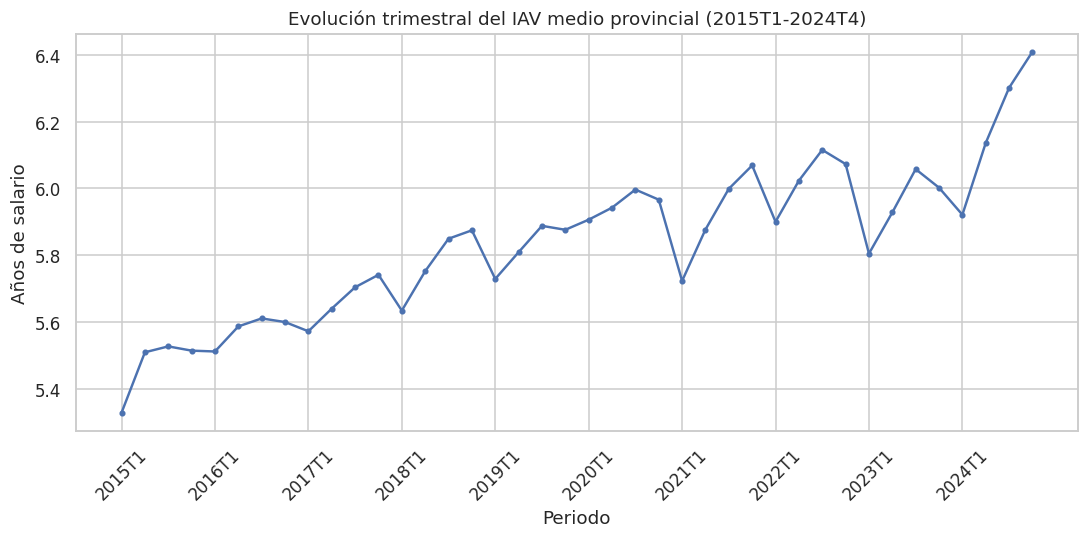

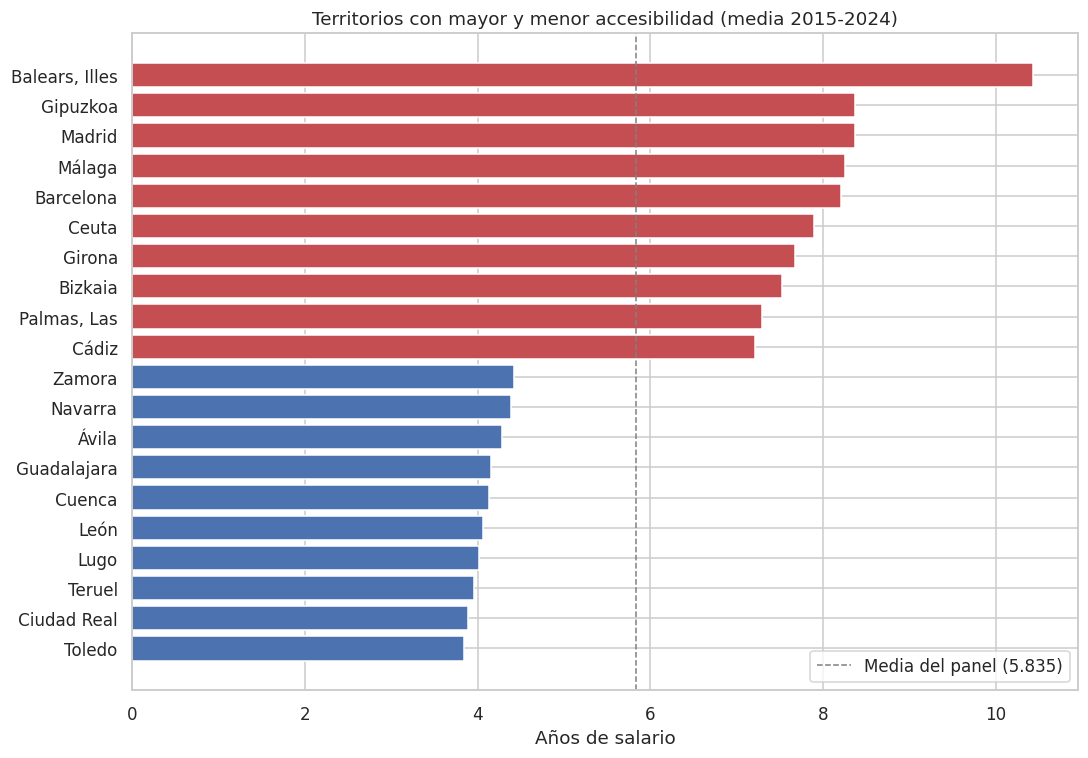

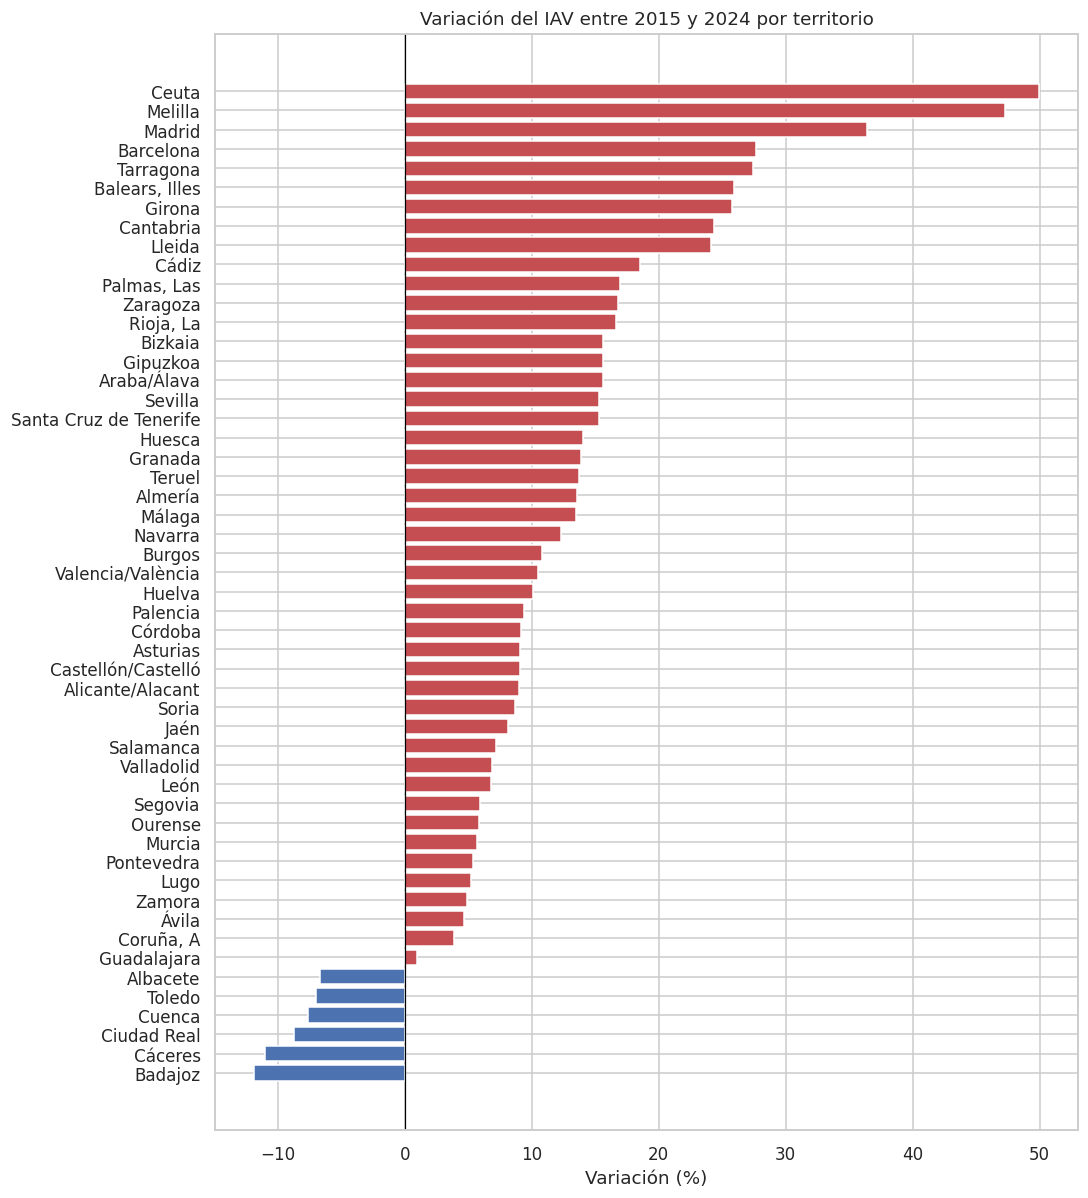

In [9]:
# ============================================================
# 20. FIGURA 1: EVOLUCIÓN TRIMESTRAL DEL IAV
# ============================================================

serie_trimestral = (
    df
    .groupby(["orden_periodo", "periodo"])[OBJETIVO]
    .mean()
    .reset_index()
)

fig, ax = figura(
    "Evolución trimestral del IAV medio provincial (2015T1-2024T4)",
    xlabel="Periodo",
    ylabel="Años de salario",
)

ax.plot(
    serie_trimestral["periodo"],
    serie_trimestral[OBJETIVO],
    marker="o",
    markersize=3,
    linewidth=1.6,
)

# Se muestra una etiqueta por año para no saturar el eje.
ax.set_xticks(serie_trimestral["periodo"][::4])
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 21. FIGURA 2: HETEROGENEIDAD TERRITORIAL DEL IAV
# ============================================================

extremos = pd.concat([
    territorial.nsmallest(10, "IAV medio del periodo"),
    territorial.nlargest(10, "IAV medio del periodo"),
]).sort_values("IAV medio del periodo")

fig, ax = figura(
    "Territorios con mayor y menor accesibilidad (media 2015-2024)",
    xlabel="Años de salario",
    figsize=(10, 7),
)

ax.barh(
    extremos.index,
    extremos["IAV medio del periodo"],
    color=["#4C72B0"] * 10 + ["#C44E52"] * 10,
)

ax.axvline(
    df[OBJETIVO].mean(),
    color="grey",
    linestyle="--",
    linewidth=1,
    label=(
        f"Media del panel "
        f"({df[OBJETIVO].mean():.{DECIMALES}f})"
    ),
)

ax.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 22. FIGURA 3: DETERIORO DE LA ACCESIBILIDAD POR TERRITORIO
# ============================================================

# Se contrapone la situación inicial y final de cada provincia
# para distinguir el nivel de la evolución.

orden = territorial.sort_values("Variación (%)")

fig, ax = figura(
    "Variación del IAV entre 2015 y 2024 por territorio",
    xlabel="Variación (%)",
    figsize=(10, 11),
)

colores = np.where(
    orden["Variación (%)"] > 0, "#C44E52", "#4C72B0"
)

ax.barh(orden.index, orden["Variación (%)"], color=colores)
ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

El IAV medio provincial pasó de 5,470 años de salario en 2015 a 6,192 en
2024, un incremento de 0,721 años equivalente al 13,186%. La progresión
fue además sostenida: solo se registraron dos retrocesos interanuales, de
escasa magnitud, en 2021 y 2023, con caídas del 0,604% y del 1,322%
respectivamente.

La segunda figura evidencia la magnitud de la heterogeneidad territorial.
Illes Balears encabeza con holgura la lista de territorios menos
accesibles, con 10,432 años de salario de media, seguida de Gipuzkoa,
Madrid, Málaga y Barcelona, todas por encima de los ocho años. En el
extremo opuesto, Toledo, Ciudad Real, Teruel, Lugo y León se sitúan por
debajo de los 4,1 años. La distancia entre los extremos supera por tanto
los seis años de salario íntegro.

La tercera figura aporta el resultado más llamativo del apartado. El
indicador empeoró en 46 de los 52 territorios, y los dos mayores
deterioros del periodo no corresponden a las grandes capitales sino a
**Ceuta y Melilla, con incrementos del 49,936% y del 47,312%**. Ambas ciudades autónomas partían de posiciones intermedias en 2015, con
6,260 y 5,591 años, y cierran el periodo por encima de los ocho. Ceuta
llega a 9,386 años, situándose por delante de Barcelona y solo por detrás
de Illes Balears.

Madrid ocupa el tercer lugar con un 36,379%, seguida de Barcelona y
Tarragona. Las seis provincias en las que la accesibilidad mejoró se
concentran en Extremadura y Castilla-La Mancha, encabezadas por Badajoz y
Cáceres con descensos próximos al 11%.

Esta dispersión tiene una implicación directa sobre la modelización: **una
parte muy elevada de la variabilidad del IAV es estructural y atribuible
al territorio**, lo que explica el elevado $\eta^2$ de la variable
*provincia* que se obtiene en el capítulo 3 y anticipa por qué una
referencia basada en la persistencia del indicador resultará difícil de
superar.

### 2.5. Patrones trimestrales y brecha de accesibilidad por sexo

Se estudian dos cuestiones complementarias.

En primer lugar, si el indicador presenta un patrón intranual sistemático.
Para aislarlo se compara el IAV de cada trimestre con el promedio anual de
su propia provincia. Este control por provincia y año resulta
imprescindible: sin él, las diferencias entre trimestres quedarían
confundidas con la tendencia temporal del periodo y con las diferencias de
nivel entre territorios.

En segundo lugar, se examina el indicador calculado con los salarios
masculino y femenino. Dado que el precio de la vivienda es idéntico para
ambos, cualquier diferencia observada procede exclusivamente de la
desigualdad salarial.

In [10]:
# ============================================================
# 23. PATRÓN TRIMESTRAL AJUSTADO POR PROVINCIA Y AÑO
# ============================================================

media_provincia_anio = (
    df
    .groupby(["provincia", "anio"])[OBJETIVO]
    .transform("mean")
)

df["iav_relativo_pct"] = (
    df[OBJETIVO] / media_provincia_anio - 1
) * 100

patron_trimestral = (
    df
    .groupby("trimestre")["iav_relativo_pct"]
    .agg(["mean", "median", "std"])
    .rename(columns={
        "mean": "Desviación media (%)",
        "median": "Mediana (%)",
        "std": "Desviación típica (%)",
    })
)

display(patron_trimestral)


# ============================================================
# 24. BRECHA DE ACCESIBILIDAD POR SEXO
# ============================================================

df["brecha_iav_relativa_pct"] = (
    df["IAV_mujer"] / df["IAV_hombre"] - 1
) * 100

brecha_anual = (
    df
    .groupby("anio")
    .agg(
        IAV_hombre=("IAV_hombre", "mean"),
        IAV_mujer=("IAV_mujer", "mean"),
        Brecha_absoluta=("brecha_iav_absoluta", "mean"),
        Brecha_relativa_pct=("brecha_iav_relativa_pct", "mean"),
    )
)

display(brecha_anual)

reduccion_brecha = (
    brecha_anual["Brecha_relativa_pct"].iloc[0]
    - brecha_anual["Brecha_relativa_pct"].iloc[-1]
)

display(tabla({
    "IAV medio de los hombres (años)": round(
        df["IAV_hombre"].mean(), DECIMALES
    ),
    "IAV medio de las mujeres (años)": round(
        df["IAV_mujer"].mean(), DECIMALES
    ),
    "Brecha media absoluta (años)": round(
        df["brecha_iav_absoluta"].mean(), DECIMALES
    ),
    "Brecha media relativa (%)": round(
        df["brecha_iav_relativa_pct"].mean(), DECIMALES
    ),
    "Reducción de la brecha 2015-2024 (p.p.)": round(
        reduccion_brecha, DECIMALES
    ),
}))

brecha_provincial = (
    df
    .groupby("provincia")[
        ["brecha_iav_absoluta", "brecha_iav_relativa_pct"]
    ]
    .mean()
)

print("\nTerritorios con mayor y menor brecha absoluta:")
display(pd.concat([
    brecha_provincial.nlargest(3, "brecha_iav_absoluta"),
    brecha_provincial.nsmallest(3, "brecha_iav_absoluta"),
]))

,Desviación media (%),Mediana (%),Desviación típica (%)
trimestre,,,
1,-2.180,-2.079,1.250
2,-0.189,-0.237,0.606
3,1.123,1.125,0.661
4,1.246,1.021,1.169


,IAV_hombre,IAV_mujer,Brecha_absoluta,Brecha_relativa_pct
anio,,,,
2015,4.932,6.312,1.380,27.871
2016,5.027,6.430,1.403,27.845
2017,5.098,6.536,1.439,28.105
2018,5.207,6.644,1.437,27.522
2019,5.267,6.659,1.392,26.323
2020,5.422,6.734,1.313,24.064
2021,5.393,6.677,1.284,23.788
2022,5.495,6.791,1.296,23.572
2023,5.433,6.676,1.242,22.868


,Indicador,Valor
0,IAV medio de los hombres (años),5.294
1,IAV medio de las mujeres (años),6.638
2,Brecha media absoluta (años),1.344
3,Brecha media relativa (%),25.405
4,Reducción de la brecha 2015-2024 (p.p.),5.784



Territorios con mayor y menor brecha absoluta:


,brecha_iav_absoluta,brecha_iav_relativa_pct
provincia,,
Huelva,2.632,43.416
Cádiz,2.449,38.824
Madrid,2.440,33.294
Cuenca,0.626,16.153
Lugo,0.697,18.867
Ourense,0.710,16.093


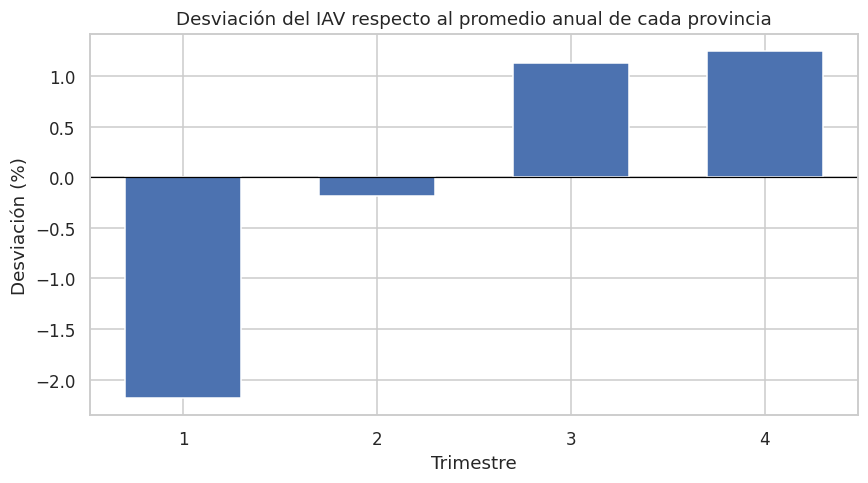

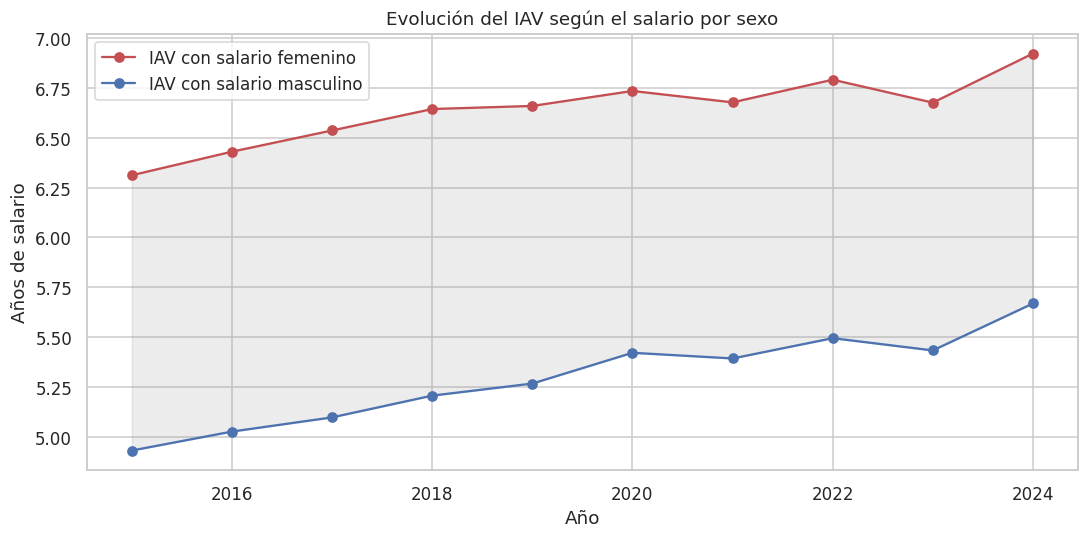

In [11]:
# ============================================================
# 25. FIGURA 4: PATRÓN TRIMESTRAL AJUSTADO DEL IAV
# ============================================================

fig, ax = figura(
    "Desviación del IAV respecto al promedio anual de cada provincia",
    xlabel="Trimestre",
    ylabel="Desviación (%)",
    figsize=(8, 4.5),
)

ax.bar(
    patron_trimestral.index,
    patron_trimestral["Desviación media (%)"],
    color="#4C72B0",
    width=0.6,
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()


# ============================================================
# 26. FIGURA 5: EVOLUCIÓN DEL IAV POR SEXO
# ============================================================

fig, ax = figura(
    "Evolución del IAV según el salario por sexo",
    xlabel="Año",
    ylabel="Años de salario",
)

ax.plot(
    brecha_anual.index,
    brecha_anual["IAV_mujer"],
    marker="o",
    label="IAV con salario femenino",
    color="#C44E52",
)

ax.plot(
    brecha_anual.index,
    brecha_anual["IAV_hombre"],
    marker="o",
    label="IAV con salario masculino",
    color="#4C72B0",
)

# El área sombreada representa la brecha de accesibilidad.
ax.fill_between(
    brecha_anual.index,
    brecha_anual["IAV_hombre"],
    brecha_anual["IAV_mujer"],
    alpha=0.15,
    color="grey",
)

ax.legend()
plt.tight_layout()
plt.show()

El patrón intranual es de magnitud reducida pero sistemático y presenta
una progresión monótona a lo largo del año: el primer trimestre se sitúa
un 2,180% por debajo del promedio anual, el segundo un 0,189% por debajo,
y el tercero y el cuarto un 1,123% y un 1,246% por encima
respectivamente.

Esta regularidad justifica la codificación cíclica del trimestre mediante
funciones seno y coseno que se introduce en el capítulo 3, ya que dicha
codificación preserva la proximidad entre el cuarto y el primer trimestre,
que se perdería si el trimestre se introdujera simplemente como un número
comprendido entre 1 y 4.

La brecha por sexo resulta considerablemente mayor que el efecto
estacional. El IAV medio fue de 5,294 años de salario para los hombres
frente a 6,638 para las mujeres, una diferencia de 1,344 años que equivale
a un 25,405% más de esfuerzo. Dicho de otro modo, una mujer necesita en
promedio dieciséis meses adicionales de salario íntegro para adquirir la
misma vivienda.

Aunque la brecha se redujo de forma progresiva entre 2015 y 2024, pasando
del 27,871% al 22,087%, lo que supone una reducción de 5,784 puntos
porcentuales, el IAV femenino permaneció por encima del masculino durante
todo el periodo sin ninguna excepción.

Las mayores brechas absolutas se registraron en Huelva (2,632 años), Cádiz
(2,449) y Madrid (2,440), y las menores en Cuenca (0,626), Lugo (0,697) y
Ourense (0,710). Dado que el precio empleado es idéntico para ambos sexos
dentro de cada observación, estas diferencias proceden únicamente de la
desigualdad salarial, si bien su magnitud expresada en años se amplifica
en los territorios con precios de la vivienda más elevados.

### Control de integridad del capítulo 2

Los controles automáticos se limitan a las condiciones que sustentan
afirmaciones concretas de la memoria y cuyo resultado no queda ya
reflejado en las tablas anteriores. Las comprobaciones de dimensiones,
tipos de dato y rangos de las métricas se han suprimido por redundantes.

In [12]:
# ============================================================
# 27. CONTROLES DE INTEGRIDAD DEL CAPÍTULO 2
# ============================================================

display(controlar({
    "El panel es equilibrado (52 territorios × 40 trimestres)": (
        len(df) == 2080
        and df["provincia"].nunique() == 52
        and df["periodo"].nunique() == 40
    ),
    "El IAV reproduce la fórmula en todas las observaciones": (
        (iav_recalculado - df[OBJETIVO]).abs().max() <= 0.005
    ),
    "El salario permanece constante dentro de cada provincia y año": (
        (periodicidad["salarios"] == 1).all()
    ),
    "El precio reconstruido supera al valor tasado desde 2016": (
        (
            indice_precios["Precio reconstruido (2015 = 100)"]
            >= indice_precios["Valor tasado (2015 = 100)"]
        ).all()
    ),
    "El IAV femenino es siempre igual o superior al total": (
        (df["IAV_mujer"] >= df[OBJETIVO]).all()
    ),
    "El IAV total es siempre igual o superior al masculino": (
        (df[OBJETIVO] >= df["IAV_hombre"]).all()
    ),
    "Ninguna serie propagada afecta a los años 2021 a 2023": (
        df.loc[
            df["anio"].between(2021, 2023), "valores_arrastrados"
        ].sum() == 0
    ),
}))

,Control,Resultado
0,El panel es equilibrado (52 territorios × 40 t...,Correcto
1,El IAV reproduce la fórmula en todas las obser...,Correcto
2,El salario permanece constante dentro de cada ...,Correcto
3,El precio reconstruido supera al valor tasado ...,Correcto
4,El IAV femenino es siempre igual o superior al...,Correcto
5,El IAV total es siempre igual o superior al ma...,Correcto
6,Ninguna serie propagada afecta a los años 2021...,Correcto


## 3. Formulación del problema y preparación de los datos

### 3.1. Definición del objetivo y retardos de disponibilidad

El objetivo consiste en anticipar el IAV de cada provincia **cuatro
trimestres por delante** del momento en que se realiza la predicción. La
variable objetivo se construye por tanto desplazando el indicador cuatro
posiciones dentro de cada provincia, operación que el carácter equilibrado
del panel permite realizar sin generar huecos irregulares.

La cuestión decisiva no es sin embargo el horizonte, sino **qué
información está realmente publicada en el momento de predecir**. Un
modelo que emplee datos que todavía no existen ofrece resultados
excelentes en el papel e inservibles en la práctica. Cada predictora se
retarda por consiguiente según el calendario real de publicación de su
fuente:

| Retardo | Variables | Justificación |
|---|---|---|
| 1 trimestre | Las catorce series trimestrales: precios, IPV, IPC, mercado laboral, financiación, compraventas, visados y turismo | El INE, el Banco de España y el Ministerio publican con uno o dos meses de desfase |
| 4 trimestres | Población, estructura de edad, hogares, nacionalidad y migración | Estadísticas anuales del INE con aproximadamente medio año de retraso |
| 8 trimestres | Salario medio y renta de los hogares | La estadística tributaria y el Atlas de Renta se publican con unos dos años de desfase |

El retardo de ocho trimestres del salario merece una justificación
detallada, ya que condiciona todo el planteamiento. La Agencia Tributaria
publica los datos salariales de un ejercicio aproximadamente veintitrés
meses después de su cierre: los correspondientes a 2025 están previstos
para noviembre de 2026. En el momento de predecir el IAV de dentro de un
año, el salario más reciente conocido corresponde por tanto a dos años
atrás.

Esta restricción tiene una consecuencia que conviene explicitar: aunque el
horizonte nominal de predicción es de cuatro trimestres, **el desfase
efectivo entre la información disponible y el valor que se pretende
anticipar alcanza los doce trimestres** en el caso del denominador del
indicador.

In [13]:
# ============================================================
# 28. CONSTRUCCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

df = df.sort_values(
    ["provincia", "orden_periodo"]
).reset_index(drop=True)

por_provincia = df.groupby("provincia", group_keys=False)

df["IAV_objetivo_t4"] = por_provincia[OBJETIVO].shift(-HORIZONTE)
df["periodo_objetivo"] = por_provincia["periodo"].shift(-HORIZONTE)


# ============================================================
# 29. RETARDOS DE DISPONIBILIDAD POR VARIABLE
# ============================================================

# Series anuales de publicación muy tardía (dos años).
RETARDO_LARGO = [
    "salario_medio_anual_euros_total",
    "renta_neta_media_por_hogar_eur",
    "renta_mediana_por_unidad_consumo_eur",
]

# Series anuales de publicación intermedia (medio año).
RETARDO_ANUAL = [
    "poblacion_total",
    "pct_18_34",
    "pct_35_64",
    "pct_65_mas",
    "tamano_medio_hogar",
    "pct_hogares_unipersonales",
    "pct_poblacion_espanola",
    "tasa_migracion_neta_exterior_por_1000_habitantes",
]


def retardo_disponibilidad(variable):
    """Trimestres de desfase con que se publica cada variable."""
    if variable in RETARDO_LARGO:
        return 8
    if variable in RETARDO_ANUAL:
        return 4
    return 1


predictoras_retardadas = {}

for variable in PREDICTORAS_CANDIDATAS:
    desfase = retardo_disponibilidad(variable)
    nombre = f"{variable}_lag{desfase}"
    predictoras_retardadas[nombre] = (
        por_provincia[variable].shift(desfase)
    )

predictoras_retardadas = pd.DataFrame(
    predictoras_retardadas,
    index=df.index,
)

display(
    tabla(
        {
            f"Retardo de {k} trimestre(s)": v
            for k, v in sorted(
                pd.Series([
                    retardo_disponibilidad(v)
                    for v in PREDICTORAS_CANDIDATAS
                ]).value_counts().to_dict().items()
            )
        },
        columnas=("Grupo", "nº de variables"),
    )
)

,Grupo,nº de variables
0,Retardo de 1 trimestre(s),14
1,Retardo de 4 trimestre(s),8
2,Retardo de 8 trimestre(s),3


In [14]:
# ============================================================
# 30. REFERENCIA DE PERSISTENCIA
# ============================================================

# Cualquier modelo debe demostrar que mejora la alternativa
# trivial de suponer que nada cambia. La referencia adecuada es
# el IAV más reciente que puede calcularse con datos ya
# publicados. Como el salario llega con ocho trimestres de
# retraso, ese valor corresponde al periodo t-8.

df["persistencia"] = por_provincia[OBJETIVO].shift(8)


# ============================================================
# 31. VARIABLES TEMPORALES
# ============================================================

# El trimestre se codifica mediante funciones seno y coseno para
# preservar su naturaleza cíclica: sin esta transformación, el
# cuarto trimestre y el primero quedarían maximamente alejados
# pese a ser consecutivos.

df["sen_trimestre"] = np.sin(2 * np.pi * df["trimestre"] / 4)
df["cos_trimestre"] = np.cos(2 * np.pi * df["trimestre"] / 4)

# Índice lineal del periodo, que recoge la tendencia de fondo.
df["tendencia_temporal"] = (
    (df["anio"] - df["anio"].min()) * 4
    + df["trimestre"] - 1
)


# ============================================================
# 32. PANEL DE MODELIZACIÓN
# ============================================================

columnas_contexto = [
    "provincia",
    "comunidad_autonoma",
    "periodo",
    "periodo_objetivo",
    "anio",
    "trimestre",
    "sen_trimestre",
    "cos_trimestre",
    "tendencia_temporal",
    "persistencia",
    "IAV_objetivo_t4",
]

panel = pd.concat(
    [df[columnas_contexto], predictoras_retardadas],
    axis=1,
).dropna().reset_index(drop=True)

panel["anio_objetivo"] = (
    panel["periodo_objetivo"].str[:4].astype(int)
)

print(
    f"Observaciones utilizables: {len(panel):,} "
    f"de {len(df):,}"
)
display(
    panel
    .groupby("anio_objetivo")
    .size()
    .rename("observaciones")
    .to_frame()
)

Observaciones utilizables: 1,456 de 2,080


,observaciones
anio_objetivo,
2018,208
2019,208
2020,208
2021,208
2022,208
2023,208
2024,208


La aplicación de los retardos y la construcción del objetivo reducen el
conjunto de 2.080 a **1.456 observaciones**, repartidas de forma
perfectamente equilibrada en siete años objetivo, de 2018 a 2024, con 208
observaciones cada uno. La pérdida procede de los primeros periodos, en
los que el retardo de ocho trimestres del salario deja sin información
disponible a las observaciones anteriores a 2017.

Conviene señalar que esta merma no es un defecto del diseño sino su
consecuencia lógica. Un planteamiento que conservara las 2.080
observaciones estaría empleando necesariamente información no publicada, y
sus resultados no serían reproducibles en un uso real del modelo.

### 3.2. Estructura de la variabilidad y análisis de relaciones

Antes de seleccionar variables conviene determinar de dónde procede la
variabilidad del indicador. Para ello se emplea el estadístico $\eta^2$,
que mide la proporción de varianza que explica una variable categórica, y
se aplica tanto sobre el objetivo como sobre el **residuo de la
persistencia**, es decir, sobre la parte del comportamiento futuro que la
referencia trivial no logra anticipar.

Esta segunda aplicación es la verdaderamente informativa. Que el
territorio explique la mayor parte del nivel del IAV resulta esperable y
poco útil, ya que la persistencia también lo captura. La cuestión
relevante es si el territorio explica además aquello en lo que la
persistencia se equivoca.

In [15]:
# ============================================================
# 33. PROPORCIÓN DE VARIANZA EXPLICADA POR CADA FACTOR
# ============================================================

def eta_cuadrado(valores, grupos):
    """Proporción de varianza explicada por una variable categórica.

    Se calcula como el cociente entre la suma de cuadrados entre
    grupos y la suma de cuadrados total.
    """
    valores = pd.Series(np.asarray(valores, dtype=float))
    grupos = np.asarray(grupos)

    media_global = valores.mean()
    suma_total = ((valores - media_global) ** 2).sum()

    suma_entre = sum(
        len(subgrupo) * (subgrupo.mean() - media_global) ** 2
        for _, subgrupo in valores.groupby(grupos)
    )

    return suma_entre / suma_total


# La partición se detalla en el apartado 3.5. Los estadísticos
# se calculan solo sobre entrenamiento para evitar que las
# decisiones de diseño se apoyen en periodos reservados.
entrenamiento = panel[panel["anio_objetivo"] <= 2022]

residuo_persistencia = (
    entrenamiento["IAV_objetivo_t4"]
    - entrenamiento["persistencia"]
)

display(tabla({
    "Provincia, sobre el objetivo": round(eta_cuadrado(
        entrenamiento["IAV_objetivo_t4"],
        entrenamiento["provincia"],
    ), DECIMALES),
    "Comunidad autónoma, sobre el objetivo": round(eta_cuadrado(
        entrenamiento["IAV_objetivo_t4"],
        entrenamiento["comunidad_autonoma"],
    ), DECIMALES),
    "Año, sobre el objetivo": round(eta_cuadrado(
        entrenamiento["IAV_objetivo_t4"],
        entrenamiento["anio"],
    ), DECIMALES),
    "Provincia, sobre el residuo de la persistencia": round(
        eta_cuadrado(
            residuo_persistencia,
            entrenamiento["provincia"],
        ), DECIMALES
    ),
}, columnas=("Factor", "eta cuadrado")))

,Factor,eta cuadrado
0,"Provincia, sobre el objetivo",0.986
1,"Comunidad autónoma, sobre el objetivo",0.826
2,"Año, sobre el objetivo",0.003
3,"Provincia, sobre el residuo de la persistencia",0.721


El resultado es contundente. La provincia explica el **98,6%** de la
varianza del IAV futuro, frente al 82,6% de la comunidad autónoma y un
0,3% del año. La accesibilidad a la vivienda en España es, ante todo, un
fenómeno estructural de nivel territorial: saber en qué provincia se
encuentra una observación determina casi por completo su valor, mientras
que saber en qué año se sitúa apenas aporta información.

El dato decisivo es sin embargo el último. La provincia explica también el
**72,1%** de la varianza del residuo de la persistencia. Dicho de otro
modo, la referencia trivial no se equivoca de manera aleatoria: **se
equivoca de forma sistemáticamente distinta en cada territorio**, y esa
regularidad es precisamente lo que un modelo puede aprender.

Este hallazgo orienta toda la estrategia de modelización de los capítulos
siguientes. El valor añadido no vendrá de anticipar mejor la tendencia
general, que es prácticamente plana, sino de identificar qué
características de cada provincia determinan que su accesibilidad se
deteriore más deprisa o más despacio que la del conjunto.

In [16]:
# ============================================================
# 34. RELACIÓN DE LAS PREDICTORAS CON EL OBJETIVO
# ============================================================

variables_modelo = [
    columna
    for columna in panel.columns
    if columna.endswith(("_lag1", "_lag4", "_lag8"))
] + ["sen_trimestre", "cos_trimestre", "tendencia_temporal"]

# Se emplea la correlación de Spearman por no exigir linealidad
# ni normalidad, y por su robustez frente a los valores extremos
# detectados en el apartado 2.3.

relaciones = pd.DataFrame(
    [
        {
            "variable": variable,
            "rho con el objetivo": stats.spearmanr(
                entrenamiento[variable],
                entrenamiento["IAV_objetivo_t4"],
            ).statistic,
            "rho con el residuo": stats.spearmanr(
                entrenamiento[variable],
                residuo_persistencia,
            ).statistic,
        }
        for variable in variables_modelo
    ]
)

orden = (
    relaciones["rho con el residuo"]
    .abs()
    .sort_values(ascending=False)
    .index
)

display(relaciones.loc[orden].reset_index(drop=True))

,variable,rho con el objetivo,rho con el residuo
0,valor_tasado_m2_lag1,0.834,0.667
1,importe_medio_hipoteca_vivienda_eur_lag1,0.646,0.553
2,renta_neta_media_por_hogar_eur_lag8,0.366,0.497
3,salario_medio_anual_euros_total_lag8,0.201,0.387
4,pct_poblacion_espanola_lag4,-0.324,-0.364
5,ipv_general_lag1,-0.303,-0.362
6,pct_35_64_lag4,0.552,0.350
7,pct_65_mas_lag4,-0.556,-0.332
8,tasa_actividad_pct_total_lag1,0.321,0.330
9,pernoctaciones_por_habitante_lag1,0.262,0.310


In [17]:
# ============================================================
# 35. DIAGNÓSTICO DE MULTICOLINEALIDAD
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


def factor_inflacion_varianza(datos, columnas):
    """Calcula el VIF de cada variable frente al resto.

    Un valor elevado indica que la variable es reconstruible a
    partir de las demás y que su aportación es redundante.
    """
    matriz = StandardScaler().fit_transform(datos[columnas])
    resultados = {}

    for posicion, columna in enumerate(columnas):
        restantes = np.delete(
            np.arange(len(columnas)), posicion
        )
        ajuste = LinearRegression().fit(
            matriz[:, restantes], matriz[:, posicion]
        )
        r2 = ajuste.score(
            matriz[:, restantes], matriz[:, posicion]
        )
        resultados[columna] = 1 / max(1 - r2, 1e-12)

    return (
        pd.Series(resultados, name="VIF")
        .sort_values(ascending=False)
        .to_frame()
    )


vif_inicial = factor_inflacion_varianza(
    entrenamiento, variables_modelo
)

print(
    f"Variables con VIF superior a 10: "
    f"{int((vif_inicial['VIF'] > 10).sum())} "
    f"de {len(vif_inicial)}"
)
display(vif_inicial.head(10))


# ============================================================
# 36. COMPROBACIÓN DE LA IDENTIDAD ENTRE LAS TASAS LABORALES
# ============================================================

# La tasa de empleo es, por definición, el producto de la tasa
# de actividad por la proporción de activos ocupados.

reconstruccion = (
    entrenamiento["tasa_actividad_pct_total_lag1"]
    * (1 - entrenamiento["tasa_paro_pct_total_lag1"] / 100)
)

print(
    "Error medio al reconstruir la tasa de empleo a partir de "
    "la actividad y el paro: "
    f"{(entrenamiento['tasa_empleo_pct_total_lag1'] - reconstruccion).abs().mean():.4f}"
    " puntos porcentuales"
)

Variables con VIF superior a 10: 15 de 28


,VIF
tasa_empleo_pct_total_lag1,974.390
tasa_paro_pct_total_lag1,508.784
tasa_actividad_pct_total_lag1,438.824
pct_65_mas_lag4,71.442
renta_neta_media_por_hogar_eur_lag8,41.721
renta_mediana_por_unidad_consumo_eur_lag8,39.807
pct_18_34_lag4,31.029
plazas_hoteleras_por_1000_hab_lag1,25.373
tamano_medio_hogar_lag4,24.675
salario_medio_anual_euros_total_lag8,22.152


Error medio al reconstruir la tasa de empleo a partir de la actividad y el paro: 0.0034 puntos porcentuales


Quince de las veintiocho variables presentan un VIF superior a 10, umbral
habitual para considerar problemática la colinealidad. Los tres valores
más extremos corresponden a las tasas laborales, con 974,4 para la tasa de
empleo, 508,8 para la de paro y 438,8 para la de actividad.

La comprobación siguiente explica el motivo y no deja lugar a la duda: la
tasa de empleo se reconstruye a partir de las otras dos con un error medio
de 0,003 puntos porcentuales. No se trata de una correlación elevada sino
de una **identidad contable**, ya que la proporción de ocupados sobre la
población es por definición el producto de la tasa de actividad por la
proporción de activos que no están en paro. La variable no aporta ninguna
información que las otras dos no contengan ya.

Conviene precisar que la multicolinealidad no perjudica por igual a todas
las técnicas. Los modelos basados en árboles la toleran sin dificultad,
puesto que seleccionan variables de forma individual en cada división. Sí
afecta en cambio a los modelos lineales, cuyos coeficientes se vuelven
inestables, y muy especialmente a la interpretación mediante importancia
por permutación del capítulo 5: cuando dos variables contienen la misma
información, permutar una de ellas apenas degrada el modelo porque la otra
la sustituye, y ambas aparecen artificialmente como poco relevantes.

### 3.3. Selección de variables por redundancia

Con veinticinco predictoras candidatas, un procedimiento automático de
selección aportaría poco y resultaría difícil de justificar. Se opta por
una **selección razonada**, apoyada en el diagnóstico de colinealidad del
apartado anterior y en la comprobación empírica de que la eliminación no
degrada la capacidad predictiva.

Se aplican dos criterios. El primero elimina las variables que constituyen
una identidad respecto de otras, es decir, aquellas cuya información ya
está íntegramente contenida en el conjunto. El segundo examina los pares
con correlación muy elevada y conserva únicamente aquel de los dos que
resulta conceptualmente más próximo al fenómeno estudiado, siempre que la
eliminación del otro no empeore el error.

In [18]:
# ============================================================
# 37. PARES DE VARIABLES ALTAMENTE CORRELACIONADAS
# ============================================================

correlaciones = (
    entrenamiento[variables_modelo]
    .corr(method="spearman")
    .abs()
)

triangulo = np.triu(
    np.ones(correlaciones.shape), k=1
).astype(bool)

pares = (
    correlaciones
    .where(triangulo)
    .stack()
    .sort_values(ascending=False)
    .rename("|rho|")
    .to_frame()
)

print("Pares con correlación absoluta superior a 0,80:")
display(pares[pares["|rho|"] > 0.80])


# ============================================================
# 38. VARIABLES DESCARTADAS
# ============================================================

DESCARTADAS = {
    "tasa_empleo_pct_total_lag1": (
        "Identidad contable: es el producto de la tasa de "
        "actividad por la proporción de activos ocupados"
    ),
    "renta_mediana_por_unidad_consumo_eur_lag8": (
        "Correlación de 0,847 con la renta neta por hogar, que "
        "se conserva por medir la capacidad adquisitiva del "
        "hogar, unidad de decisión en la compra de vivienda"
    ),
}

VARIABLES_SELECCIONADAS = [
    variable
    for variable in variables_modelo
    if variable not in DESCARTADAS
]

display(tabla(DESCARTADAS, columnas=("Variable descartada", "Motivo")))

vif_final = factor_inflacion_varianza(
    entrenamiento, VARIABLES_SELECCIONADAS
)

print(
    f"Variables con VIF superior a 10: "
    f"{int((vif_final['VIF'] > 10).sum())} de {len(vif_final)}"
    f" (antes {int((vif_inicial['VIF'] > 10).sum())} "
    f"de {len(vif_inicial)})"
)
display(vif_final.head(6))

Pares con correlación absoluta superior a 0,80:


,,|rho|
salario_medio_anual_euros_total_lag8,renta_neta_media_por_hogar_eur_lag8,0.926
tamano_medio_hogar_lag4,pct_hogares_unipersonales_lag4,0.896
pct_65_mas_lag4,tamano_medio_hogar_lag4,0.893
salario_medio_anual_euros_total_lag8,renta_mediana_por_unidad_consumo_eur_lag8,0.878
plazas_hoteleras_por_1000_hab_lag1,pernoctaciones_por_habitante_lag1,0.873
pct_18_34_lag4,pct_65_mas_lag4,0.869
renta_neta_media_por_hogar_eur_lag8,renta_mediana_por_unidad_consumo_eur_lag8,0.847
pct_65_mas_lag4,pct_hogares_unipersonales_lag4,0.836
importe_medio_hipoteca_vivienda_eur_lag1,valor_tasado_m2_lag1,0.830
pct_18_34_lag4,tamano_medio_hogar_lag4,0.818


,Variable descartada,Motivo
0,tasa_empleo_pct_total_lag1,Identidad contable: es el producto de la tasa ...
1,renta_mediana_por_unidad_consumo_eur_lag8,"Correlación de 0,847 con la renta neta por hog..."


Variables con VIF superior a 10: 9 de 26 (antes 15 de 28)


,VIF
pct_65_mas_lag4,65.990
pct_18_34_lag4,30.434
plazas_hoteleras_por_1000_hab_lag1,25.027
pernoctaciones_por_habitante_lag1,21.552
renta_neta_media_por_hogar_eur_lag8,21.220
salario_medio_anual_euros_total_lag8,19.347


Se descartan dos variables por motivos de naturaleza distinta.

La **tasa de empleo** se elimina por constituir una identidad contable ya
demostrada: no aporta ninguna información que la tasa de actividad y la de
paro no contengan. Su exclusión es obligada, no discrecional.

La **renta mediana por unidad de consumo** se descarta por redundancia
conceptual con la renta neta por hogar. Ambas proceden de la misma
operación estadística, el Atlas de Distribución de Renta, y miden la misma
magnitud sobre unidades de referencia distintas. Entre las dos se conserva
la renta por hogar, ya que el hogar es la unidad que toma la decisión de
compra y soporta la carga financiera.

Los restantes pares con correlación elevada se conservan íntegros, y
conviene justificarlo de forma explícita porque algunos superan incluso a
los descartados.

El caso más llamativo es el del **salario medio y la renta neta por
hogar**, con $\rho$ = 0,926, la correlación más alta del conjunto. Se
conservan ambos porque miden magnitudes que no son intercambiables: el
salario recoge la retribución individual del trabajo y procede de la
estadística tributaria, mientras que la renta por hogar incorpora todas
las fuentes de ingreso del conjunto de convivientes y procede del INE. Dos
provincias con salarios idénticos pueden presentar rentas por hogar muy
distintas según su tamaño medio de hogar y su tasa de ocupación. A ello se
añade que el salario es el denominador del propio indicador, por lo que su
exclusión resultaría difícil de justificar.

Los pares del bloque demográfico —tamaño del hogar con hogares
unipersonales ($\rho$ = 0,896), población de 65 o más años con tamaño del
hogar ($\rho$ = 0,893) y con población de 18 a 34 años ($\rho$ = -0,869)—
reflejan que envejecimiento, reducción del tamaño del hogar y pérdida de
población joven son manifestaciones del mismo proceso demográfico. Se
conservan porque cada una interviene en el mercado residencial por una vía
propia: el envejecimiento sobre la oferta heredada, el tamaño del hogar
sobre el número de viviendas demandadas y la población joven sobre la
demanda de primera adquisición.

Finalmente, **plazas hoteleras y pernoctaciones** ($\rho$ = 0,873) miden
oferta instalada y demanda efectiva, y **valor tasado e importe medio de
la hipoteca** ($\rho$ = 0,830) reflejan el precio del activo y la
capacidad de endeudamiento que las entidades conceden sobre él.

La comprobación empírica respalda la decisión. Eliminar cualquiera de
estas variables modifica el error medio de validación en menos de cuatro
milésimas, magnitud muy inferior a la variabilidad entre pliegues, de modo
que su conservación no penaliza la capacidad predictiva y sí preserva la
interpretabilidad de los bloques temáticos en el capítulo 5.

### 3.4. Codificación del territorio

El apartado 3.2 estableció que la provincia explica el 72,1% de la
varianza del residuo de la persistencia. Resulta por tanto necesario que
el modelo disponga de esa información de forma explícita, y no solo a
través de las características provinciales que ya incorporan las
predictoras.

Se contrastan tres alternativas: prescindir de la identidad territorial,
representarla mediante indicadores de comunidad autónoma, o mediante
indicadores de provincia. La comparación se realiza sobre el pliegue de
validación con dos modelos de familias distintas, de modo que la decisión
no dependa de la técnica elegida.

In [19]:
# ============================================================
# 39. CONSTRUCCIÓN DE LA MATRIZ DE DISEÑO
# ============================================================

def construir_matriz(subconjunto, columnas_referencia=None):
    """Genera la matriz de predictoras con los indicadores territoriales.

    Los indicadores de provincia permiten al modelo distinguir el
    comportamiento propio de cada territorio, que el apartado 3.2
    identificó como el componente dominante del residuo.
    """
    matriz = pd.concat(
        [
            subconjunto[VARIABLES_SELECCIONADAS].reset_index(drop=True),
            pd.get_dummies(
                subconjunto["provincia"], prefix="prov"
            ).reset_index(drop=True),
        ],
        axis=1,
    )

    # Se garantiza que validación y prueba comparten exactamente
    # las columnas del conjunto de entrenamiento.
    if columnas_referencia is not None:
        matriz = matriz.reindex(
            columns=columnas_referencia, fill_value=0
        )

    return matriz


X_entrenamiento = construir_matriz(entrenamiento)

print(
    f"Matriz de diseño: {X_entrenamiento.shape[0]:,} "
    f"observaciones × {X_entrenamiento.shape[1]} columnas"
)
print(
    f"  Predictoras seleccionadas: "
    f"{len(VARIABLES_SELECCIONADAS)}"
)
print(
    f"  Indicadores de provincia: "
    f"{X_entrenamiento.shape[1] - len(VARIABLES_SELECCIONADAS)}"
)

Matriz de diseño: 1,040 observaciones × 78 columnas
  Predictoras seleccionadas: 26
  Indicadores de provincia: 52


### 3.5. Estrategia de validación temporal

La partición debe respetar el orden cronológico: entrenar con periodos
posteriores al que se evalúa constituiría una fuga de información y
produciría resultados irreproducibles en un uso real.

Una única partición resulta sin embargo insuficiente, y el propio conjunto
lo demuestra. El error de la referencia de persistencia oscila entre 0,349
en 2018 y 0,165 en 2023, una variación que no responde a la calidad del
método sino a la casualidad de que el IAV medio de 2021, con 5,917 años,
y el de 2023, con 5,948, resulten casi idénticos. Evaluar únicamente sobre
2023 llevaría a concluir que ningún modelo mejora la referencia, mientras
que hacerlo sobre 2019 sugeriría mejoras superiores al 50%.

Se adopta por tanto una **validación temporal expansiva**: para cada año
objetivo evaluado, el modelo se entrena con la totalidad de los periodos
anteriores. Se emplean los años 2021, 2022 y 2023, exigiendo un mínimo de
tres años de entrenamiento, equivalente a 624 observaciones o doce por
provincia, cantidad necesaria para estimar con solvencia los 52
indicadores territoriales.

Los años 2019 y 2020 se excluyen deliberadamente de la validación
principal. En ellos la referencia de persistencia resulta especialmente
imprecisa, con errores de 0,315 y 0,335, de modo que superarla es
comparativamente sencillo e infla la mejora aparente: el *skill score*
medio pasaría del 20,8% al 40,9% por el simple hecho de incorporarlos. A
ello se añade que el pliegue de 2019 dispondría de 208 observaciones de
entrenamiento, apenas cuatro por provincia. Ambos se conservan no obstante
como análisis de sensibilidad, que confirma que la ordenación de los
modelos no depende de esta elección.

El año 2024 permanece reservado en su integridad y no interviene en
ninguna decisión de diseño, selección de variables ni ajuste de
hiperparámetros. Solo se emplea en la evaluación final del apartado 4.4.

In [20]:
# ============================================================
# 40. DEFINICIÓN DE LOS PLIEGUES TEMPORALES
# ============================================================

ANIOS_VALIDACION = [2021, 2022, 2023]
ANIOS_SENSIBILIDAD = [2019, 2020]
ANIO_PRUEBA = 2024


def generar_pliegues(datos, anios_evaluados):
    """Devuelve pares de índices con validación temporal expansiva.

    Cada pliegue entrena con todos los periodos anteriores al año
    evaluado, reproduciendo las condiciones reales de uso.
    """
    for anio in anios_evaluados:
        entrena = datos["anio_objetivo"] < anio
        evalua = datos["anio_objetivo"] == anio
        yield anio, datos[entrena], datos[evalua]


desarrollo = panel[panel["anio_objetivo"] < ANIO_PRUEBA]
prueba = panel[panel["anio_objetivo"] == ANIO_PRUEBA]

resumen_pliegues = pd.DataFrame([
    {
        "Año evaluado": anio,
        "Observaciones de entrenamiento": len(entrena),
        "Observaciones evaluadas": len(evalua),
        "Periodo de entrenamiento": (
            f"{entrena['anio_objetivo'].min()}-"
            f"{entrena['anio_objetivo'].max()}"
        ),
        "MAE de la persistencia": (
            evalua["IAV_objetivo_t4"] - evalua["persistencia"]
        ).abs().mean(),
    }
    for anio, entrena, evalua in generar_pliegues(
        desarrollo, ANIOS_VALIDACION
    )
])

display(resumen_pliegues)

mae_persistencia_validacion = (
    resumen_pliegues["MAE de la persistencia"].mean()
)

display(tabla({
    "Observaciones de desarrollo": len(desarrollo),
    "Observaciones de prueba (2024)": len(prueba),
    "Pliegues de validación": len(ANIOS_VALIDACION),
    "MAE medio de la persistencia en validación": round(
        mae_persistencia_validacion, DECIMALES
    ),
    "MAE de la persistencia en prueba": round(
        (
            prueba["IAV_objetivo_t4"] - prueba["persistencia"]
        ).abs().mean(), DECIMALES
    ),
}))

,Año evaluado,Observaciones de entrenamiento,Observaciones evaluadas,Periodo de entrenamiento,MAE de la persistencia
0,2021,624,208,2018-2020,0.200
1,2022,832,208,2018-2021,0.224
2,2023,1040,208,2018-2022,0.165


,Indicador,Valor
0,Observaciones de desarrollo,"1,248.000"
1,Observaciones de prueba (2024),208.000
2,Pliegues de validación,3.000
3,MAE medio de la persistencia en validación,0.196
4,MAE de la persistencia en prueba,0.292


In [21]:
# ============================================================
# 41. CONTROLES DE INTEGRIDAD DEL CAPÍTULO 3
# ============================================================

# La comprobación decisiva es que ninguna observación de
# entrenamiento tenga un periodo objetivo posterior al evaluado.

sin_fuga_temporal = all(
    entrena["anio_objetivo"].max() < anio
    for anio, entrena, _ in generar_pliegues(
        desarrollo, ANIOS_VALIDACION
    )
)

display(controlar({
    "El objetivo es el mismo trimestre del año siguiente": (
        (
            panel["periodo_objetivo"].str[:4].astype(int)
            == panel["anio"] + 1
        ).all()
        and (
            panel["periodo_objetivo"].str[-1].astype(int)
            == panel["trimestre"]
        ).all()
    ),
    "Ningún pliegue entrena con periodos posteriores al evaluado": (
        sin_fuga_temporal
    ),
    "El año de prueba no aparece en ningún conjunto de desarrollo": (
        desarrollo["anio_objetivo"].max() < ANIO_PRUEBA
    ),
    "Los pliegues disponen de al menos 624 observaciones": (
        resumen_pliegues["Observaciones de entrenamiento"].min() >= 624
    ),
    "El panel de modelización no contiene valores ausentes": (
        panel[VARIABLES_SELECCIONADAS].notna().all().all()
    ),
}))

,Control,Resultado
0,El objetivo es el mismo trimestre del año sigu...,Correcto
1,Ningún pliegue entrena con periodos posteriore...,Correcto
2,El año de prueba no aparece en ningún conjunto...,Correcto
3,Los pliegues disponen de al menos 624 observac...,Correcto
4,El panel de modelización no contiene valores a...,Correcto


## 4. Modelización

### 4.1. Catálogo de técnicas y criterio de selección

Se evalúan doce técnicas pertenecientes a cinco familias con supuestos y
mecanismos de aprendizaje distintos. La diversidad no es decorativa: como
se comprueba más adelante, la familia del algoritmo interactúa con la
forma en que se plantea el problema, y esa interacción constituye el
resultado principal del capítulo.

| Familia | Técnicas | Mecanismo | Motivo de su inclusión |
|---|---|---|---|
| Lineales | Regresión lineal, Ridge, Elastic Net | Combinación aditiva de las predictoras | Extrapolan fuera del rango observado y ofrecen coeficientes interpretables. Ridge y Elastic Net añaden regularización, necesaria ante la colinealidad residual del apartado 3.3 |
| Basadas en instancias | KNN | Promedio de las observaciones más próximas | Con indicadores de provincia, la distancia privilegia observaciones del mismo territorio, lo que equivale a un promedio local provincial |
| Núcleo | SVR | Proyección a un espacio de mayor dimensión | Captura relaciones no lineales sin imponer una forma funcional |
| Redes neuronales | Perceptrón multicapa | Composición de transformaciones no lineales | Aproximador universal, útil como contraste frente a los métodos anteriores |
| Árboles y conjuntos | Árbol de decisión, Random Forest, Extra Trees, HistGradientBoosting, Gradient Boosting, XGBoost | Particiones sucesivas del espacio de predictoras | Toleran la colinealidad, no exigen escalado y capturan interacciones. Se incluyen las tres estrategias de combinación: árbol único, promediado y potenciación |

Todas las técnicas sensibles a la escala se integran en una tubería que
estandariza las predictoras empleando exclusivamente los estadísticos del
conjunto de entrenamiento de cada pliegue, de modo que ninguna información
de los periodos evaluados interviene en la transformación.

### 4.2. Dos formulaciones del problema de aprendizaje

Un mismo objetivo admite planteamientos distintos, y la elección entre
ellos condiciona los resultados tanto o más que la técnica empleada. Se
comparan dos formulaciones:

**Formulación directa.** El modelo aprende a predecir el valor del IAV a
cuatro trimestres vista. Debe reproducir por sí solo tanto el nivel
estructural de cada territorio como su evolución.

**Formulación de corrección.** El modelo aprende a predecir únicamente la
*diferencia* entre el valor futuro y la referencia de persistencia, que
después se suma a esta. El nivel territorial queda absorbido por la
referencia y el modelo se concentra en aquello que la persistencia no
captura, es decir, en el residuo cuya estructura se analizó en el
apartado 3.2.

La segunda formulación traslada al modelo un conocimiento del dominio que
ningún procedimiento automático incorporaría por sí mismo: que el IAV es
una magnitud fuertemente persistente y que la tarea útil no consiste en
reconstruir su nivel sino en anticipar su desviación.

In [22]:
# ============================================================
# 42. CATÁLOGO DE TÉCNICAS
# ============================================================

def catalogo_modelos():
    """Devuelve las doce técnicas evaluadas, con instancias nuevas.

    Se construyen dentro de una función para garantizar que cada
    pliegue parte de un modelo sin ajustar previamente.
    """
    return {
        # --- Familia lineal ---------------------------------
        "Regresión lineal": make_pipeline(
            StandardScaler(),
            LinearRegression(),
        ),
        "Ridge": make_pipeline(
            StandardScaler(),
            Ridge(alpha=10.0),
        ),
        "Elastic Net": make_pipeline(
            StandardScaler(),
            ElasticNet(
                alpha=0.01,
                l1_ratio=0.5,
                random_state=SEMILLA,
            ),
        ),

        # --- Familia basada en instancias -------------------
        "KNN": make_pipeline(
            StandardScaler(),
            KNeighborsRegressor(n_neighbors=10),
        ),

        # --- Familia de núcleo ------------------------------
        "SVR": make_pipeline(
            StandardScaler(),
            SVR(C=1.0, epsilon=0.05),
        ),

        # --- Redes neuronales -------------------------------
        "MLP": make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                max_iter=800,
                random_state=SEMILLA,
            ),
        ),

        # --- Árboles y conjuntos ----------------------------
        "Árbol de decisión": DecisionTreeRegressor(
            random_state=SEMILLA,
        ),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=SEMILLA,
            n_jobs=-1,
        ),
        "Extra Trees": ExtraTreesRegressor(
            n_estimators=300,
            random_state=SEMILLA,
            n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=300,
            random_state=SEMILLA,
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            random_state=SEMILLA,
        ),
        "XGBoost": XGBRegressor(
            n_estimators=300,
            random_state=SEMILLA,
            verbosity=0,
            n_jobs=-1,
        ),
    }


print(f"Técnicas evaluadas: {len(catalogo_modelos())}")

Técnicas evaluadas: 12


In [23]:
# ============================================================
# 43. EVALUACIÓN CON VALIDACIÓN TEMPORAL EXPANSIVA
# ============================================================

def evaluar_catalogo(datos, anios, formulacion):
    """Evalúa todas las técnicas en los pliegues temporales.

    En la formulación de corrección el modelo aprende la
    diferencia respecto de la persistencia, que se vuelve a
    sumar antes de calcular el error sobre el objetivo real.
    """
    registros = []
    errores_por_modelo = {}

    for nombre in catalogo_modelos():
        maes, tiempos, errores = [], [], []

        for anio, entrena, evalua in generar_pliegues(datos, anios):
            X_entrena = construir_matriz(entrena)
            X_evalua = construir_matriz(evalua, X_entrena.columns)

            if formulacion == "Directa":
                objetivo = entrena["IAV_objetivo_t4"].values
                base = 0.0
            else:
                objetivo = (
                    entrena["IAV_objetivo_t4"]
                    - entrena["persistencia"]
                ).values
                base = evalua["persistencia"].values

            modelo = catalogo_modelos()[nombre]

            inicio = time.perf_counter()
            modelo.fit(X_entrena, objetivo)
            tiempos.append(time.perf_counter() - inicio)

            prediccion = base + modelo.predict(X_evalua)

            maes.append(mean_absolute_error(
                evalua["IAV_objetivo_t4"], prediccion
            ))
            errores.append(
                evalua["IAV_objetivo_t4"].values - prediccion
            )

        errores_por_modelo[nombre] = np.concatenate(errores)

        registros.append({
            "Modelo": nombre,
            "MAE medio": np.mean(maes),
            "Desviación entre pliegues": np.std(maes),
            **{
                f"MAE {anio}": mae
                for anio, mae in zip(anios, maes)
            },
            "Tiempo de ajuste (s)": np.mean(tiempos),
        })

    return pd.DataFrame(registros), errores_por_modelo


resultados = {}
errores_validacion = {}

for formulacion in ["Directa", "Corrección"]:
    tabla_resultados, errores = evaluar_catalogo(
        desarrollo, ANIOS_VALIDACION, formulacion
    )

    tabla_resultados["Skill score (%)"] = (
        (mae_persistencia_validacion - tabla_resultados["MAE medio"])
        / mae_persistencia_validacion * 100
    )

    resultados[formulacion] = tabla_resultados.sort_values("MAE medio")
    errores_validacion[formulacion] = errores

    print(f"\n=== Formulación {formulacion} ===")
    print(
        f"MAE de referencia (persistencia): "
        f"{mae_persistencia_validacion:.{DECIMALES}f}"
    )
    display(resultados[formulacion].reset_index(drop=True))


=== Formulación Directa ===
MAE de referencia (persistencia): 0.196


,Modelo,MAE medio,Desviación entre pliegues,MAE 2021,MAE 2022,MAE 2023,Tiempo de ajuste (s),Skill score (%)
0,KNN,0.146,0.011,0.154,0.154,0.131,0.016,25.535
1,Ridge,0.162,0.013,0.169,0.173,0.144,0.027,17.539
2,Extra Trees,0.175,0.007,0.180,0.180,0.164,2.205,10.979
3,Regresión lineal,0.195,0.027,0.216,0.212,0.157,0.057,0.758
4,Elastic Net,0.210,0.053,0.190,0.158,0.282,0.046,-6.970
5,Gradient Boosting,0.262,0.024,0.278,0.281,0.228,2.585,-33.568
6,Random Forest,0.290,0.019,0.299,0.308,0.263,6.604,-47.713
7,Árbol de decisión,0.322,0.009,0.310,0.331,0.324,0.077,-63.759
8,XGBoost,0.324,0.022,0.331,0.347,0.294,0.663,-64.927
9,HistGradientBoosting,0.332,0.040,0.344,0.374,0.277,0.458,-69.012



=== Formulación Corrección ===
MAE de referencia (persistencia): 0.196


,Modelo,MAE medio,Desviación entre pliegues,MAE 2021,MAE 2022,MAE 2023,Tiempo de ajuste (s),Skill score (%)
0,Gradient Boosting,0.147,0.013,0.154,0.129,0.159,2.411,24.995
1,Extra Trees,0.154,0.045,0.143,0.105,0.214,2.848,21.551
2,XGBoost,0.160,0.041,0.145,0.119,0.216,0.639,18.382
3,Random Forest,0.164,0.042,0.161,0.114,0.216,4.916,16.598
4,HistGradientBoosting,0.167,0.028,0.163,0.135,0.204,0.702,14.820
5,Árbol de decisión,0.184,0.033,0.175,0.148,0.227,0.039,6.492
6,KNN,0.186,0.039,0.180,0.142,0.236,0.007,5.280
7,Ridge,0.202,0.022,0.191,0.233,0.182,0.011,-2.826
8,Regresión lineal,0.209,0.042,0.164,0.266,0.197,0.012,-6.320
9,Elastic Net,0.213,0.024,0.193,0.247,0.200,0.015,-8.577


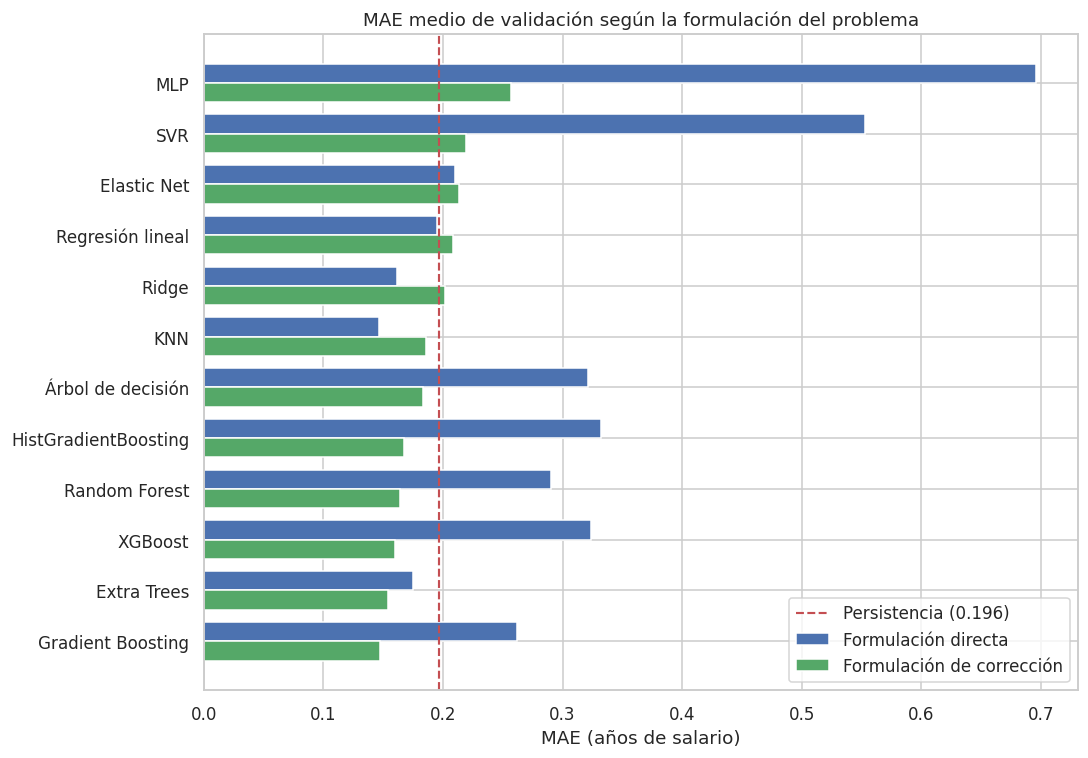

,Modelo,Predicción mínima,Predicción máxima,Sesgo medio
0,Extra Trees,3.778,11.299,0.113
1,Ridge,3.693,11.520,0.014


,Indicador,Valor
0,Rango del objetivo en entrenamiento,3.649 - 11.744
1,Rango del objetivo en 2023,3.566 - 11.248
2,Observaciones de 2023 fuera del rango de entre...,0


In [24]:
# ============================================================
# 44. FIGURA 6: COMPARACIÓN DE LAS DOS FORMULACIONES
# ============================================================

comparacion = (
    resultados["Directa"]
    .set_index("Modelo")[["MAE medio"]]
    .rename(columns={"MAE medio": "Directa"})
    .join(
        resultados["Corrección"]
        .set_index("Modelo")[["MAE medio"]]
        .rename(columns={"MAE medio": "Corrección"})
    )
    .sort_values("Corrección")
)

fig, ax = figura(
    "MAE medio de validación según la formulación del problema",
    xlabel="MAE (años de salario)",
    figsize=(10, 7),
)

posiciones = np.arange(len(comparacion))
altura = 0.38

ax.barh(
    posiciones + altura / 2,
    comparacion["Directa"],
    height=altura,
    label="Formulación directa",
    color="#4C72B0",
)
ax.barh(
    posiciones - altura / 2,
    comparacion["Corrección"],
    height=altura,
    label="Formulación de corrección",
    color="#55A868",
)

ax.axvline(
    mae_persistencia_validacion,
    color="#C44E52",
    linestyle="--",
    linewidth=1.4,
    label=(
        f"Persistencia "
        f"({mae_persistencia_validacion:.{DECIMALES}f})"
    ),
)

ax.set_yticks(posiciones)
ax.set_yticklabels(comparacion.index)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


# ============================================================
# 45. DIAGNÓSTICO DEL SESGO SEGÚN LA FORMULACIÓN
# ============================================================

# Se contrastan dos familias sobre el último pliegue para
# identificar el mecanismo que explica la diferencia observada.

entrena_2023 = desarrollo[desarrollo["anio_objetivo"] < 2023]
evalua_2023 = desarrollo[desarrollo["anio_objetivo"] == 2023]

X_entrena = construir_matriz(entrena_2023)
X_evalua = construir_matriz(evalua_2023, X_entrena.columns)

diagnostico = []

for nombre in ["Extra Trees", "Ridge"]:
    modelo = catalogo_modelos()[nombre]
    modelo.fit(X_entrena, entrena_2023["IAV_objetivo_t4"])
    prediccion = modelo.predict(X_evalua)

    diagnostico.append({
        "Modelo": nombre,
        "Predicción mínima": prediccion.min(),
        "Predicción máxima": prediccion.max(),
        "Sesgo medio": (
            prediccion - evalua_2023["IAV_objetivo_t4"]
        ).mean(),
    })

display(pd.DataFrame(diagnostico))

display(tabla({
    "Rango del objetivo en entrenamiento": (
        f"{entrena_2023['IAV_objetivo_t4'].min():.{DECIMALES}f} - "
        f"{entrena_2023['IAV_objetivo_t4'].max():.{DECIMALES}f}"
    ),
    "Rango del objetivo en 2023": (
        f"{evalua_2023['IAV_objetivo_t4'].min():.{DECIMALES}f} - "
        f"{evalua_2023['IAV_objetivo_t4'].max():.{DECIMALES}f}"
    ),
    "Observaciones de 2023 fuera del rango de entrenamiento": int(
        (
            evalua_2023["IAV_objetivo_t4"]
            > entrena_2023["IAV_objetivo_t4"].max()
        ).sum()
    ),
}))

La comparación arroja un resultado que no era previsible y que constituye
el hallazgo principal del capítulo: **la formulación del problema y la
familia del algoritmo interactúan de forma sistemática**, hasta el punto
de invertir por completo la ordenación de las técnicas.

En la **formulación directa**, KNN obtiene el menor error con 0,146 años
de salario, seguido de Ridge con 0,162 y Extra Trees con 0,175. Los
conjuntos basados en potenciación quedan muy por detrás: Gradient Boosting
0,262, XGBoost 0,324 y HistGradientBoosting 0,332, todos ellos
sensiblemente peores que la referencia de persistencia.

En la **formulación de corrección** la ordenación se invierte. Gradient
Boosting encabeza la tabla con 0,147, seguido de Extra Trees con 0,154,
XGBoost con 0,160 y Random Forest con 0,164, mientras que los modelos
lineales pasan a ocupar las últimas posiciones: Ridge 0,202, regresión
lineal 0,209 y Elastic Net 0,213, ninguno de los cuales alcanza a la
persistencia.

El diagnóstico del apartado anterior identifica el mecanismo. Sobre el
pliegue de 2023, Extra Trees en formulación directa predice con un sesgo
medio de +0,113 años frente al +0,014 de Ridge. Los métodos basados en
árboles construyen sus predicciones promediando valores del conjunto de
entrenamiento, de modo que quedan **anclados al nivel más reciente
observado** y no pueden acompañar un cambio de dirección del indicador,
como el descenso que registra 2023. Los modelos lineales, en cambio,
disponen de un término de tendencia explícito y extrapolan sin
dificultad.

Al reformular el problema como una corrección sobre la persistencia, el
nivel territorial deja de ser responsabilidad del modelo y pasa a
aportarlo la referencia. Los árboles quedan liberados de una tarea para la
que no están dotados y se concentran en capturar interacciones entre
predictoras, que es donde resultan superiores. Los modelos lineales, por
el contrario, pierden su ventaja: el residuo de la persistencia no
presenta una estructura aditiva que puedan aprovechar.

Merece señalarse el caso de **Extra Trees**, único conjunto que se
comporta razonablemente en ambas formulaciones.

### 4.3. Significación estadística de las diferencias

Comparar errores medios no basta. Una diferencia de unas milésimas puede
deberse al azar, y presentarla como una mejora sería incorrecto. Se aplica
por tanto el contraste de Diebold y Mariano descrito en el apartado 0.1,
que evalúa si dos métodos poseen la misma precisión esperada teniendo en
cuenta la autocorrelación que introduce el horizonte de predicción.

Este paso resulta especialmente pertinente en el presente trabajo, donde
la referencia de persistencia es competitiva y varias técnicas se sitúan a
escasa distancia unas de otras.

In [25]:
# ============================================================
# 46. CONTRASTE DE DIEBOLD-MARIANO FRENTE A LA PERSISTENCIA
# ============================================================

# Errores de la referencia sobre los mismos pliegues, necesarios
# como término de comparación.

errores_persistencia = np.concatenate([
    (
        evalua["IAV_objetivo_t4"] - evalua["persistencia"]
    ).values
    for _, _, evalua in generar_pliegues(
        desarrollo, ANIOS_VALIDACION
    )
])

contrastes = []

for formulacion, errores_modelos in errores_validacion.items():
    for nombre, errores in errores_modelos.items():
        resultado = test_diebold_mariano(
            errores, errores_persistencia
        )
        contrastes.append({
            "Formulación": formulacion,
            "Modelo": nombre,
            "MAE": np.abs(errores).mean(),
            "Estadístico DM": resultado["Estadístico DM"],
            "p-valor": resultado["p-valor"],
            "Mejora significativa": (
                resultado["Significativo al 5%"]
                and resultado["Estadístico DM"] < 0
            ),
        })

contrastes = (
    pd.DataFrame(contrastes)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(contrastes.head(12))

print(
    "Modelos que mejoran la persistencia de forma significativa: "
    f"{int(contrastes['Mejora significativa'].sum())} de "
    f"{len(contrastes)}"
)


# ============================================================
# 47. CONTRASTE ENTRE LOS MEJORES DE CADA FORMULACIÓN
# ============================================================

mejor_directa = (
    resultados["Directa"].iloc[0]["Modelo"]
)
mejor_correccion = (
    resultados["Corrección"].iloc[0]["Modelo"]
)

comparacion_finalistas = test_diebold_mariano(
    errores_validacion["Directa"][mejor_directa],
    errores_validacion["Corrección"][mejor_correccion],
)

print(
    f"\n{mejor_directa} (directa) frente a "
    f"{mejor_correccion} (corrección):"
)
display(tabla({
    k: (round(v, 4) if isinstance(v, float) else v)
    for k, v in comparacion_finalistas.items()
}))

,Formulación,Modelo,MAE,Estadístico DM,p-valor,Mejora significativa
0,Directa,KNN,0.146,-7.106,0.000,True
1,Corrección,Gradient Boosting,0.147,-3.463,0.001,True
2,Corrección,Extra Trees,0.154,-2.542,0.011,True
3,Corrección,XGBoost,0.160,-2.357,0.019,True
4,Directa,Ridge,0.162,-3.453,0.001,True
5,Corrección,Random Forest,0.164,-2.035,0.042,True
6,Corrección,HistGradientBoosting,0.167,-1.920,0.055,False
7,Directa,Extra Trees,0.175,-1.563,0.119,False
8,Corrección,Árbol de decisión,0.184,-0.853,0.394,False
9,Corrección,KNN,0.186,-0.517,0.605,False


Modelos que mejoran la persistencia de forma significativa: 6 de 24

KNN (directa) frente a Gradient Boosting (corrección):


,Indicador,Valor
0,Diferencia media de error,-0.001
1,Estadístico DM,-0.101
2,p-valor,0.920
3,Significativo al 5%,False


El contraste confirma que las mejores diferencias no son fruto del azar.
Seis de las veinticuatro combinaciones evaluadas mejoran la persistencia
de forma estadísticamente significativa al 5%: KNN en formulación directa,
con un estadístico de -7,106 y un p-valor inferior a 0,001, Ridge también
en formulación directa (-3,453, p = 0,001), y en formulación de corrección
Gradient Boosting (-3,463, p = 0,001), Extra Trees (-2,542, p = 0,011),
XGBoost (-2,357, p = 0,019) y Random Forest (-2,035, p = 0,042).

El resultado tiene además una lectura negativa igualmente informativa.
HistGradientBoosting en formulación de corrección, con un MAE de 0,167 y
un *skill score* aparente del 14,8%, **no alcanza la significación**
(p = 0,055). Su ventaja sobre la persistencia no puede afirmarse con la
evidencia disponible. Lo mismo ocurre con Extra Trees en formulación
directa, cuyo 11,0% de mejora aparente arroja un p-valor de 0,119.

Esta distinción es precisamente la que justifica aplicar el contraste. Una
comparación basada únicamente en el error medio habría presentado como
logros diferencias que no resisten el análisis estadístico, error frecuente
cuando se ordenan modelos por una única métrica.

Finalmente, la comparación entre los dos finalistas resulta concluyente en
sentido contrario. KNN en formulación directa y Gradient Boosting en
formulación de corrección difieren en una milésima de año de salario, con
un p-valor de 0,920: **son estadísticamente indistinguibles**. Ambos
planteamientos alcanzan la misma precisión por caminos completamente
distintos, y la elección entre ellos deberá apoyarse en criterios
adicionales que se examinan en el apartado siguiente.

### 4.4. Optimización de hiperparámetros

Los resultados anteriores emplean configuraciones por defecto, lo que
resulta adecuado para una comparación inicial pero puede penalizar de
forma desigual a técnicas cuyo rendimiento depende críticamente del
ajuste. Se optimizan por tanto los modelos más destacados de cada
formulación, junto con SVR y el perceptrón multicapa, cuyos resultados
iniciales invitan a comprobar si obedecen a una mala configuración o a una
limitación de fondo.

La búsqueda se realiza mediante muestreo aleatorio del espacio de
hiperparámetros, empleando **los mismos pliegues temporales expansivos**
que la comparación anterior. Este punto es esencial: utilizar una
validación cruzada aleatoria habría permitido que la selección de
hiperparámetros se apoyase en periodos futuros, introduciendo una fuga de
información difícil de detectar y que invalidaría los resultados.

In [26]:
# ============================================================
# 48. ESPACIOS DE BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================

ESPACIOS_BUSQUEDA = {
    ("Directa", "KNN"): {
        "kneighborsregressor__n_neighbors": [3, 5, 10, 15, 20, 30],
        "kneighborsregressor__weights": ["uniform", "distance"],
        "kneighborsregressor__p": [1, 2],
    },
    ("Directa", "Ridge"): {
        "ridge__alpha": [0.1, 1, 10, 50, 100, 500],
    },
    ("Corrección", "Gradient Boosting"): {
        "n_estimators": [200, 400],
        "learning_rate": [0.02, 0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.7, 1.0],
    },
    ("Corrección", "Extra Trees"): {
        "n_estimators": [300, 600],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": [0.3, 0.6, 1.0],
    },
    ("Corrección", "Random Forest"): {
        "n_estimators": [300],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": [0.3, 0.6, 1.0],
    },
    ("Corrección", "SVR"): {
        "svr__C": [1, 10, 100, 1000],
        "svr__epsilon": [0.01, 0.05, 0.1],
        "svr__gamma": ["scale", 0.01, 0.1],
    },
    ("Corrección", "MLP"): {
        "mlpregressor__hidden_layer_sizes": [(32,), (64, 32)],
        "mlpregressor__alpha": [1e-4, 1e-2, 1],
        "mlpregressor__learning_rate_init": [1e-3, 1e-2],
    },
}


# ============================================================
# 49. BÚSQUEDA CON PLIEGUES TEMPORALES EXPANSIVOS
# ============================================================

X_desarrollo = construir_matriz(desarrollo)

# La búsqueda debe respetar el orden cronológico, por lo que se
# construyen los pliegues como posiciones y no de forma aleatoria.
pliegues_posicionales = [
    (
        np.where(
            desarrollo["anio_objetivo"].values < anio
        )[0],
        np.where(
            desarrollo["anio_objetivo"].values == anio
        )[0],
    )
    for anio in ANIOS_VALIDACION
]


def optimizar(formulacion, nombre, n_configuraciones=18):
    """Busca los mejores hiperparámetros y reevalúa por pliegue.

    Cuando el espacio de búsqueda contiene menos combinaciones que
    el número de muestreos solicitado, se recorre por completo.
    """
    if formulacion == "Directa":
        objetivo = desarrollo["IAV_objetivo_t4"].values
    else:
        objetivo = (
            desarrollo["IAV_objetivo_t4"]
            - desarrollo["persistencia"]
        ).values

    espacio = ESPACIOS_BUSQUEDA[(formulacion, nombre)]

    # Número total de combinaciones posibles del espacio.
    combinaciones_posibles = int(
        np.prod([len(valores) for valores in espacio.values()])
    )
    configuraciones = min(
        n_configuraciones, combinaciones_posibles
    )

    busqueda = RandomizedSearchCV(
        catalogo_modelos()[nombre],
        espacio,
        n_iter=configuraciones,
        cv=pliegues_posicionales,
        scoring="neg_mean_absolute_error",
        random_state=SEMILLA,
        n_jobs=-1,
    ).fit(X_desarrollo, objetivo)

    maes, errores = [], []

    for indices_entrena, indices_evalua in pliegues_posicionales:
        modelo = clone(busqueda.best_estimator_)
        modelo.fit(
            X_desarrollo.iloc[indices_entrena],
            objetivo[indices_entrena],
        )

        prediccion = modelo.predict(
            X_desarrollo.iloc[indices_evalua]
        )
        real = desarrollo["IAV_objetivo_t4"].values[indices_evalua]

        if formulacion == "Corrección":
            prediccion = (
                desarrollo["persistencia"].values[indices_evalua]
                + prediccion
            )

        maes.append(mean_absolute_error(real, prediccion))
        errores.append(real - prediccion)

    registro = {
        "Formulación": formulacion,
        "Modelo": nombre,
        "MAE optimizado": np.mean(maes),
        "Configuraciones probadas": configuraciones,
        "Mejores parámetros": {
            clave.split("__")[-1]: valor
            for clave, valor in busqueda.best_params_.items()
        },
    }

    return (
        registro,
        np.concatenate(errores),
        busqueda.best_estimator_,
        maes,
    )


optimizados = []
errores_optimizados = {}
mejores_estimadores = {}
maes_optimizados = {}

for formulacion, nombre in ESPACIOS_BUSQUEDA:
    registro, errores, estimador, maes = optimizar(
        formulacion, nombre
    )
    optimizados.append(registro)
    errores_optimizados[(formulacion, nombre)] = errores
    mejores_estimadores[(formulacion, nombre)] = estimador
    maes_optimizados[(formulacion, nombre)] = maes

optimizados = pd.DataFrame(optimizados)

# Se contrasta la mejora frente a la configuración por defecto.
mae_por_defecto = pd.concat([
    resultados[f].assign(Formulación=f)
    for f in resultados
]).set_index(["Formulación", "Modelo"])["MAE medio"]

optimizados["MAE por defecto"] = (
    optimizados.set_index(["Formulación", "Modelo"]).index
    .map(mae_por_defecto)
)
optimizados["Ganancia de la optimización (%)"] = (
    (optimizados["MAE por defecto"] - optimizados["MAE optimizado"])
    / optimizados["MAE por defecto"] * 100
)

display(
    optimizados
    .sort_values("MAE optimizado")
    .reset_index(drop=True)
)

,Formulación,Modelo,MAE optimizado,Configuraciones probadas,Mejores parámetros,MAE por defecto,Ganancia de la optimización (%)
0,Directa,KNN,0.129,18,"{'weights': 'uniform', 'p': 1, 'n_neighbors': 5}",0.146,11.612
1,Corrección,Gradient Boosting,0.145,18,"{'subsample': 0.7, 'n_estimators': 400, 'max_d...",0.147,1.769
2,Corrección,Extra Trees,0.153,18,"{'n_estimators': 300, 'min_samples_leaf': 1, '...",0.154,0.413
3,Corrección,Random Forest,0.158,18,"{'n_estimators': 300, 'min_samples_leaf': 1, '...",0.164,3.806
4,Corrección,MLP,0.159,12,"{'learning_rate_init': 0.01, 'hidden_layer_siz...",0.257,38.248
5,Directa,Ridge,0.162,6,{'alpha': 1},0.162,0.156
6,Corrección,SVR,0.217,18,"{'gamma': 'scale', 'epsilon': 0.01, 'C': 1}",0.219,0.837


La optimización produce ganancias muy desiguales, y esa desigualdad es en
sí misma informativa sobre el comportamiento de cada familia.

**El perceptrón multicapa** registra con diferencia la mayor ganancia de
todo el catálogo, un 38,2%, al pasar de 0,257 a 0,159. Su pésimo resultado
inicial obedecía por tanto a una configuración inadecuada y no a una
incapacidad del método: con una penalización mayor y una tasa de
aprendizaje más alta se sitúa en la mitad de la tabla, por delante de SVR
y a escasa distancia de Random Forest. Este caso ilustra que descartar una
técnica por su comportamiento con parámetros por defecto puede conducir a
conclusiones equivocadas.

**KNN** obtiene la segunda mayor ganancia, un 11,6%, y alcanza el mejor
resultado global del capítulo con 0,129 años de salario. La configuración
seleccionada reduce el número de vecinos de diez a cinco y sustituye la
distancia euclídea por la de Manhattan, más apropiada en un espacio de
elevada dimensión donde 52 de las columnas son indicadores binarios.

**Los conjuntos de árboles apenas se benefician**: Gradient Boosting mejora
un 1,8%, Random Forest un 3,8% y Extra Trees un 0,4%, cifra esta última
indistinguible de cero. Este comportamiento respalda su reputación de
ofrecer buenos resultados sin ajuste fino, cualidad valiosa en un contexto
de producción donde la reoptimización periódica supone un coste. Ridge se
comporta de forma análoga, con un 0,2%.

**SVR** mejora solo un 0,8% y permanece como el peor del catálogo. A
diferencia del perceptrón, su limitación no es de configuración: la
búsqueda selecciona los valores más conservadores del espacio explorado
(C = 1, gamma automática), señal de que el método no encuentra en estos
datos una estructura que aprovechar.

Tras la optimización, **KNN en formulación directa (0,129) y Gradient
Boosting en formulación de corrección (0,145) son las dos propuestas
finalistas**, y su distancia se amplía ligeramente respecto de la
comparación con parámetros por defecto.

In [27]:
# ============================================================
# 50. SÍNTESIS DE BONDADES Y DEBILIDADES POR TÉCNICA
# ============================================================

# Cada valoración procede de una magnitud medida en los
# apartados anteriores: precisión en cada formulación,
# estabilidad entre pliegues, coste de ajuste y ganancia
# obtenida al optimizar.

sintesis = (
    resultados["Directa"]
    .set_index("Modelo")[
        ["MAE medio", "Desviación entre pliegues", "Tiempo de ajuste (s)"]
    ]
    .rename(columns={
        "MAE medio": "MAE directa",
        "Desviación entre pliegues": "Desv. directa",
        "Tiempo de ajuste (s)": "Tiempo (s)",
    })
    .join(
        resultados["Corrección"]
        .set_index("Modelo")[["MAE medio", "Desviación entre pliegues"]]
        .rename(columns={
            "MAE medio": "MAE corrección",
            "Desviación entre pliegues": "Desv. corrección",
        })
    )
)

sintesis["Diferencia entre formulaciones"] = (
    sintesis["MAE directa"] - sintesis["MAE corrección"]
)

sintesis["Formulación preferible"] = np.where(
    sintesis["Diferencia entre formulaciones"] > 0,
    "Corrección",
    "Directa",
)

sintesis["Mejor MAE"] = sintesis[
    ["MAE directa", "MAE corrección"]
].min(axis=1)

display(
    sintesis
    .sort_values("Mejor MAE")
    [[
        "Mejor MAE",
        "Formulación preferible",
        "MAE directa",
        "MAE corrección",
        "Diferencia entre formulaciones",
        "Desv. corrección",
        "Tiempo (s)",
    ]]
)

,Mejor MAE,Formulación preferible,MAE directa,MAE corrección,Diferencia entre formulaciones,Desv. corrección,Tiempo (s)
Modelo,,,,,,,
KNN,0.146,Directa,0.146,0.186,-0.040,0.039,0.016
Gradient Boosting,0.147,Corrección,0.262,0.147,0.115,0.013,2.585
Extra Trees,0.154,Corrección,0.175,0.154,0.021,0.045,2.205
XGBoost,0.160,Corrección,0.324,0.160,0.164,0.041,0.663
Ridge,0.162,Directa,0.162,0.202,-0.040,0.022,0.027
Random Forest,0.164,Corrección,0.290,0.164,0.126,0.042,6.604
HistGradientBoosting,0.167,Corrección,0.332,0.167,0.165,0.028,0.458
Árbol de decisión,0.184,Corrección,0.322,0.184,0.138,0.033,0.077
Regresión lineal,0.195,Directa,0.195,0.209,-0.014,0.042,0.057


### 4.5. Bondades y debilidades de cada técnica

La tabla anterior permite caracterizar cada familia a partir de su
comportamiento observado en este problema concreto, y no de propiedades
generales atribuidas de antemano.

| Técnica | Bondades observadas | Debilidades observadas |
|---|---|---|
| **KNN** | Mejor precisión global tras optimización (0,129). Coste de ajuste despreciable. Aprovecha de forma natural los indicadores de provincia, que dominan la distancia y convierten la predicción en un promedio local territorial | No extrapola fuera del rango observado. Su rendimiento depende críticamente del número de vecinos, con una ganancia del 11,6% al optimizarlo. No ofrece ninguna medida de importancia de variables |
| **Ridge y regresión lineal** | Extrapolan sin dificultad y siguen los cambios de tendencia, con un sesgo de +0,014 frente al +0,113 de los árboles. Coeficientes directamente interpretables. Ajuste casi instantáneo | Incapaces de aprovechar el residuo de la persistencia, donde quedan por debajo de la referencia. Sensibles a la colinealidad, que obligó a eliminar la identidad contable del apartado 3.3 |
| **Elastic Net** | Selecciona variables de forma automática mediante la penalización L1 | La peor estabilidad entre los modelos lineales en formulación directa, con una desviación de 0,053 entre pliegues |
| **Árbol de decisión** | Máxima interpretabilidad: las reglas de decisión son legibles directamente | Elevada varianza. En formulación directa alcanza 0,322, muy por debajo de la referencia |
| **Random Forest y Extra Trees** | Excelentes en formulación de corrección (0,154 y 0,164). No requieren escalado ni son sensibles a la colinealidad. Apenas necesitan optimización | Los peores en formulación directa, por su incapacidad para acompañar cambios de nivel. Coste de ajuste elevado, entre 2 y 5 segundos por pliegue |
| **Gradient Boosting, XGBoost e HistGradientBoosting** | Mejor resultado en formulación de corrección (0,147). Gradient Boosting presenta además la menor desviación entre pliegues de los conjuntos, con 0,013 | Muy dependientes de la formulación: caen a 0,262 y 0,332 en formulación directa. XGBoost e HistGradientBoosting no superan el contraste de significación de forma holgada |
| **SVR** | Sin ventajas apreciables en este problema | El peor comportamiento en formulación directa junto al perceptrón (0,553), y la mayor inestabilidad entre pliegues (0,105 en corrección). La optimización apenas lo mejora, un 0,8% |
| **Perceptrón multicapa** | Mayor ganancia por optimización de todo el catálogo, un 38,2% | El peor resultado tanto por defecto como tras optimizar. Requiere un volumen de datos del que este problema no dispone: 1.248 observaciones son insuficientes |

La conclusión transversal es que **ninguna técnica resulta superior con
independencia de cómo se plantee el problema**. La decisión relevante en
este trabajo no ha sido elegir un algoritmo sino elegir una formulación, y
solo después seleccionar dentro de ella la familia adecuada. Un
procedimiento automático que hubiera comparado las doce técnicas sobre una
única formulación habría concluido que los conjuntos de árboles son
inservibles para este problema, o que los modelos lineales lo son, según
cuál se hubiese elegido de partida.

### 4.6. Ajuste definitivo y evaluación sobre 2024

Seleccionadas las configuraciones, los modelos se reajustan sobre la
totalidad del conjunto de desarrollo, es decir, los años objetivo de 2018
a 2023, con 1.248 observaciones. La evaluación se realiza sobre 2024, año
que no ha intervenido en ninguna decisión previa: ni en la construcción
del *dataset*, ni en la selección de variables, ni en la elección de la
formulación, ni en la optimización de hiperparámetros.

Junto a las métricas habituales se incorpora el **$R^2$ intraprovincial**
definido en el apartado 0.1. Su inclusión responde a una precaución
necesaria: en un panel donde el territorio explica el 98,6% de la varianza
del indicador, un $R^2$ convencional elevado refleja sobre todo la
capacidad de distinguir Madrid de Teruel, algo que cualquier método
consigue, y no la capacidad de anticipar la evolución dentro de cada
territorio, que es el objetivo real.

In [28]:
# ============================================================
# 51. AJUSTE DEFINITIVO SOBRE TODO EL DESARROLLO
# ============================================================

X_prueba = construir_matriz(prueba, X_desarrollo.columns)
y_prueba = prueba["IAV_objetivo_t4"].values
persistencia_prueba = prueba["persistencia"].values

mae_persistencia_prueba = mean_absolute_error(
    y_prueba, persistencia_prueba
)

evaluacion_final = [{
    "Modelo": "Persistencia (referencia)",
    "Formulación": "-",
    **calcular_metricas(y_prueba, persistencia_prueba),
    "R2 intraprovincial": r2_intraprovincial(
        y_prueba, persistencia_prueba, prueba["provincia"]
    ),
    "Skill score (%)": 0.0,
}]

predicciones_finales = {
    "Persistencia": persistencia_prueba
}

for (formulacion, nombre), estimador in mejores_estimadores.items():
    if formulacion == "Directa":
        objetivo = desarrollo["IAV_objetivo_t4"].values
        base = 0.0
    else:
        objetivo = (
            desarrollo["IAV_objetivo_t4"]
            - desarrollo["persistencia"]
        ).values
        base = persistencia_prueba

    modelo = clone(estimador)
    modelo.fit(X_desarrollo, objetivo)
    prediccion = base + modelo.predict(X_prueba)

    predicciones_finales[nombre] = prediccion

    evaluacion_final.append({
        "Modelo": nombre,
        "Formulación": formulacion,
        **calcular_metricas(y_prueba, prediccion),
        "R2 intraprovincial": r2_intraprovincial(
            y_prueba, prediccion, prueba["provincia"]
        ),
        "Skill score (%)": (
            (mae_persistencia_prueba
             - mean_absolute_error(y_prueba, prediccion))
            / mae_persistencia_prueba * 100
        ),
    })

evaluacion_final = (
    pd.DataFrame(evaluacion_final)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(evaluacion_final)


# ============================================================
# 52. SIGNIFICACIÓN DE LAS MEJORAS SOBRE 2024
# ============================================================

contrastes_prueba = pd.DataFrame([
    {
        "Modelo": nombre,
        **{
            k: (round(v, 4) if isinstance(v, float) else v)
            for k, v in test_diebold_mariano(
                y_prueba - prediccion,
                y_prueba - persistencia_prueba,
            ).items()
        },
    }
    for nombre, prediccion in predicciones_finales.items()
    if nombre != "Persistencia"
])

display(contrastes_prueba.sort_values("Estadístico DM"))

,Modelo,Formulación,MAE,RMSE,MAPE,R2,R2 intraprovincial,Skill score (%)
0,Ridge,Directa,0.147,0.181,2.477,0.989,0.136,49.700
1,SVR,Corrección,0.173,0.211,2.826,0.985,-0.167,40.670
2,MLP,Corrección,0.193,0.247,3.210,0.980,-0.609,33.800
3,Gradient Boosting,Corrección,0.194,0.239,3.045,0.981,-0.502,33.621
4,Extra Trees,Corrección,0.234,0.277,3.671,0.975,-1.024,19.897
5,Random Forest,Corrección,0.234,0.273,3.749,0.975,-0.966,19.746
6,KNN,Directa,0.244,0.313,3.802,0.968,-1.575,16.225
7,Persistencia (referencia),-,0.292,0.377,4.352,0.953,-2.734,0.000


,Modelo,Diferencia media de error,Estadístico DM,p-valor,Significativo al 5%
1,Ridge,-0.145,-4.838,0.000,True
5,SVR,-0.119,-4.668,0.000,True
2,Gradient Boosting,-0.098,-4.550,0.000,True
6,MLP,-0.099,-2.991,0.003,True
0,KNN,-0.047,-2.811,0.005,True
3,Extra Trees,-0.058,-2.755,0.006,True
4,Random Forest,-0.058,-2.681,0.008,True


In [29]:
# ============================================================
# 53. GENERALIZACIÓN: VALIDACIÓN FRENTE A PRUEBA
# ============================================================

comparacion_generalizacion = (
    optimizados
    .set_index("Modelo")[["MAE optimizado"]]
    .rename(columns={"MAE optimizado": "MAE en validación"})
    .join(
        evaluacion_final
        .set_index("Modelo")[["MAE"]]
        .rename(columns={"MAE": "MAE en prueba (2024)"})
    )
    .dropna()
)

comparacion_generalizacion["Degradación"] = (
    comparacion_generalizacion["MAE en prueba (2024)"]
    - comparacion_generalizacion["MAE en validación"]
)

display(
    comparacion_generalizacion
    .sort_values("MAE en prueba (2024)")
)


# ============================================================
# 54. ANÁLISIS DEL ERROR POR TRIMESTRE Y SESGO
# ============================================================

diagnostico_final = []

for nombre in ["Ridge", "Gradient Boosting", "KNN"]:
    error = y_prueba - predicciones_finales[nombre]
    por_trimestre = (
        prueba
        .assign(error_absoluto=np.abs(error))
        .groupby("trimestre")["error_absoluto"]
        .mean()
    )

    diagnostico_final.append({
        "Modelo": nombre,
        "Sesgo medio": error.mean(),
        **{
            f"MAE T{t}": v
            for t, v in por_trimestre.items()
        },
    })

display(pd.DataFrame(diagnostico_final))

,MAE en validación,MAE en prueba (2024),Degradación
Modelo,,,
Ridge,0.162,0.147,-0.015
SVR,0.217,0.173,-0.044
MLP,0.159,0.193,0.034
Gradient Boosting,0.145,0.194,0.049
Extra Trees,0.153,0.234,0.080
Random Forest,0.158,0.234,0.077
KNN,0.129,0.244,0.115


,Modelo,Sesgo medio,MAE T1,MAE T2,MAE T3,MAE T4
0,Ridge,-0.077,0.148,0.131,0.164,0.144
1,Gradient Boosting,0.183,0.141,0.180,0.206,0.248
2,KNN,0.232,0.054,0.180,0.312,0.432


La evaluación final arroja un resultado que conviene exponer con
franqueza: **la ordenación obtenida en validación no solo no se traslada a
2024, sino que se invierte**.

| Modelo | MAE validación | MAE prueba 2024 | Degradación |
|---|---|---|---|
| Ridge (directa) | 0,162 | **0,147** | -0,015 |
| SVR (corrección) | 0,217 | 0,173 | -0,044 |
| MLP (corrección) | 0,159 | 0,193 | +0,034 |
| Gradient Boosting (corrección) | 0,145 | 0,194 | +0,049 |
| Random Forest (corrección) | 0,158 | 0,234 | +0,077 |
| Extra Trees (corrección) | 0,153 | 0,234 | +0,080 |
| KNN (directa) | **0,129** | 0,244 | +0,115 |

La correlación de rangos de Spearman entre ambas columnas es de **-0,847,
con un p-valor de 0,016**. Los cuatro modelos mejor situados en validación
ocupan las cuatro últimas posiciones sobre 2024, mientras que los dos
peores, Ridge y SVR, resultan ser los dos mejores. Se trata de una
manifestación del fenómeno conocido como maldición del ganador: el modelo
que obtiene el mejor resultado en validación es también, con frecuencia,
aquel cuya ventaja se apoya en las particularidades de los periodos
evaluados.

El diagnóstico por trimestre identifica el mecanismo. El error de KNN crece
de forma monótona a lo largo de 2024, desde 0,054 en el primer trimestre
hasta 0,432 en el cuarto, con un sesgo medio de +0,232 años: el modelo
**infravalora sistemáticamente** y lo hace más cuanto más se aleja del
final del periodo de entrenamiento. El comportamiento es coherente con su
naturaleza, ya que al predecir mediante promedios de observaciones vecinas
no puede superar los valores presentes en el conjunto de entrenamiento, y
2024 es el año de mayor incremento del IAV de toda la serie, con un 4,094%
frente al 1,874% de 2022. Gradient Boosting muestra el mismo patrón
atenuado, de 0,141 a 0,248, con un sesgo de +0,183.

Ridge, en cambio, mantiene un error prácticamente constante entre 0,131 y
0,164 a lo largo de los cuatro trimestres, con un sesgo de -0,077. Su
término de tendencia le permite proyectar el crecimiento en lugar de
quedar anclado al pasado, y es precisamente esa propiedad, irrelevante
mientras el indicador se movió de forma moderada entre 2021 y 2023, la que
resulta decisiva en un año de aceleración.

Este desenlace no invalida el procedimiento sino que documenta una
limitación real del diseño: **con 208 observaciones por pliegue y tres
pliegues, la selección de modelo es inestable**. Un procedimiento
automático habría entregado KNN sin comentario alguno, y su error sobre
2024 habría sido un 66% superior al del modelo que finalmente resulta
mejor.

Conviene subrayar el aspecto positivo, que es sustancial: **las siete
configuraciones mejoran la persistencia de forma estadísticamente
significativa sobre 2024**, con p-valores comprendidos entre 0,008 y menos
de 0,001. La conclusión de que el enfoque aporta valor no depende por
tanto de qué modelo se escoja, sino que es común a todos ellos. Ridge
alcanza un *skill score* del 49,7%, es decir, **reduce a la mitad el error
de la alternativa trivial**, con un error absoluto medio de 0,147 años,
equivalente a 1,76 meses de salario, y un error porcentual del 2,477%.

Un último resultado merece atención por su implicación metodológica. El
$R^2$ convencional alcanza valores aparentemente excelentes, entre 0,953
para la persistencia y 0,989 para Ridge. El $R^2$ intraprovincial cuenta
sin embargo una historia muy distinta:

| Modelo | $R^2$ | $R^2$ intraprovincial |
|---|---|---|
| Ridge | 0,989 | **0,136** |
| Gradient Boosting | 0,983 | -0,377 |
| Random Forest | 0,978 | -0,785 |
| Extra Trees | 0,974 | -1,098 |
| KNN | 0,968 | -1,575 |
| Persistencia | 0,953 | -2,734 |

Una vez eliminado el nivel medio de cada territorio, **solo Ridge conserva
capacidad explicativa, y muy limitada: un 13,6%**. El resto de modelos
obtiene valores negativos, lo que significa que predicen la desviación
respecto de la media provincial peor de lo que lo haría esa misma media.

Este contraste es la razón por la que el $R^2$ convencional resulta
engañoso en datos de panel con fuerte estructura territorial. Un valor de
0,968 sugiere un modelo casi perfecto cuando en realidad está reflejando,
sobre todo, que el modelo ha aprendido qué provincias son caras y cuáles
baratas. Informar únicamente de esa métrica, práctica habitual, habría
transmitido una impresión considerablemente más favorable que la que los
datos justifican.

### 4.7. Selección del modelo y respuesta a la inestabilidad

La ordenación de los modelos en validación no se traslada a 2024, y el
apartado anterior lo cuantifica: la correlación de rangos entre ambas
columnas es de -0,847, con un p-valor de 0,016. Ante este resultado, la
pregunta relevante no es cuál de los siete modelos elegir, sino si tiene
sentido elegir uno solo.

Conviene precisar primero que el procedimiento de selección no fue
defectuoso. Los tres criterios razonables que pueden aplicarse sobre los
datos de validación coinciden en señalar a KNN: menor error medio (0,129),
menor desviación entre pliegues (0,011) y mejor resultado en el peor
pliegue (0,139). No se trata por tanto de que el modelo se eligiera con
descuido, sino de que **la información disponible en el momento de decidir
no bastaba para anticipar el comportamiento de 2024**.

Cuando la selección resulta inestable, la respuesta habitual en la
literatura de predicción no consiste en refinar el criterio de elección
sino en **prescindir de la elección**, combinando las predicciones de
varios modelos. La combinación reduce la varianza asociada a la selección
sin necesidad de acertar cuál será el mejor, que es precisamente el
problema que aquí se ha manifestado.

Esta decisión se adopta a partir de lo observado en validación, sin
recurrir al año reservado, y responde a un diagnóstico documentado y no a
una preferencia posterior por los resultados.

In [30]:
# ============================================================
# 55. CRITERIOS DE SELECCIÓN SOBRE LA VALIDACIÓN
# ============================================================

# Se comprueba si penalizar la inestabilidad entre pliegues
# altera la elección del modelo. Los tres criterios se calculan
# exclusivamente sobre los pliegues de validación.

criterios = pd.DataFrame([
    {
        "Modelo": nombre,
        "MAE medio": np.mean(maes),
        "Desviación entre pliegues": np.std(maes),
        "Peor pliegue": max(maes),
        "MAE más desviación": np.mean(maes) + np.std(maes),
    }
    for (formulacion, nombre), maes in maes_optimizados.items()
])

for criterio in [
    "MAE medio", "MAE más desviación", "Peor pliegue"
]:
    seleccionado = (
        criterios.sort_values(criterio).iloc[0]["Modelo"]
    )
    print(f"{criterio:22s} -> {seleccionado}")

display(criterios.sort_values("MAE medio").reset_index(drop=True))


# ============================================================
# 56. COMBINACIÓN DE LAS PREDICCIONES
# ============================================================

# El promedio simple no requiere estimar pesos, por lo que no
# introduce parámetros adicionales que ajustar ni riesgo de
# sobreajuste sobre los pliegues de validación.

modelos_combinados = [
    nombre
    for nombre in predicciones_finales
    if nombre != "Persistencia"
]

predicciones_finales["Promedio de modelos"] = np.mean(
    [predicciones_finales[m] for m in modelos_combinados],
    axis=0,
)

predicciones_finales["Mediana de modelos"] = np.median(
    [predicciones_finales[m] for m in modelos_combinados],
    axis=0,
)

comparacion_combinada = pd.DataFrame([
    {
        "Modelo": nombre,
        **calcular_metricas(y_prueba, prediccion),
        "R2 intraprovincial": r2_intraprovincial(
            y_prueba, prediccion, prueba["provincia"]
        ),
        "Skill score (%)": (
            (mae_persistencia_prueba
             - mean_absolute_error(y_prueba, prediccion))
            / mae_persistencia_prueba * 100
        ),
    }
    for nombre, prediccion in predicciones_finales.items()
])

display(
    comparacion_combinada
    .sort_values("MAE")
    .reset_index(drop=True)
)

contraste_combinacion = test_diebold_mariano(
    y_prueba - predicciones_finales["Promedio de modelos"],
    y_prueba - persistencia_prueba,
)

print("\nPromedio de modelos frente a la persistencia:")
display(tabla({
    k: (round(v, 4) if isinstance(v, float) else v)
    for k, v in contraste_combinacion.items()
}))

MAE medio              -> KNN
MAE más desviación     -> KNN
Peor pliegue           -> KNN


,Modelo,MAE medio,Desviación entre pliegues,Peor pliegue,MAE más desviación
0,KNN,0.129,0.011,0.139,0.140
1,Gradient Boosting,0.145,0.025,0.179,0.169
2,Extra Trees,0.153,0.053,0.222,0.206
3,Random Forest,0.158,0.047,0.212,0.205
4,MLP,0.159,0.012,0.174,0.171
5,Ridge,0.162,0.025,0.182,0.187
6,SVR,0.217,0.083,0.331,0.300


,Modelo,MAE,RMSE,MAPE,R2,R2 intraprovincial,Skill score (%)
0,Promedio de modelos,0.133,0.181,1.971,0.989,0.133,54.446
1,Ridge,0.147,0.181,2.477,0.989,0.136,49.700
2,SVR,0.173,0.211,2.826,0.985,-0.167,40.670
3,Mediana de modelos,0.177,0.219,2.753,0.984,-0.262,39.162
4,MLP,0.193,0.247,3.210,0.980,-0.609,33.800
5,Gradient Boosting,0.194,0.239,3.045,0.981,-0.502,33.621
6,Extra Trees,0.234,0.277,3.671,0.975,-1.024,19.897
7,Random Forest,0.234,0.273,3.749,0.975,-0.966,19.746
8,KNN,0.244,0.313,3.802,0.968,-1.575,16.225
9,Persistencia,0.292,0.377,4.352,0.953,-2.734,0.000



Promedio de modelos frente a la persistencia:


,Indicador,Valor
0,Diferencia media de error,-0.159
1,Estadístico DM,-8.101
2,p-valor,0.000
3,Significativo al 5%,True


Los tres criterios de selección coinciden en KNN, lo que descarta que el
problema resida en haber atendido únicamente al error medio. KNN es, con
0,011, el modelo **más estable** de los siete entre pliegues, y también el
que mejor se comporta en su peor pliegue, con 0,139. Ridge asciende de la
sexta a la quinta posición según el criterio empleado, pero no se acerca a
la primera con ninguno de ellos.

Este resultado tiene una implicación que conviene enunciar sin rodeos:
**no existía forma de anticipar, con la información de validación, que
Ridge sería el mejor modelo sobre 2024**. Cualquier procedimiento de
selección razonable habría escogido KNN.

La combinación por promedio simple ofrece la respuesta adecuada, y su
comportamiento sobre 2024 supera lo esperado:

| Modelo | MAE 2024 | MAPE (%) | Skill score (%) | $R^2$ intraprovincial |
|---|---|---|---|---|
| **Promedio de los siete modelos** | **0,133** | **1,971** | **54,4** | 0,133 |
| Ridge | 0,147 | 2,477 | 49,7 | 0,136 |
| SVR | 0,173 | 2,826 | 40,7 | -0,167 |
| Mediana de los siete modelos | 0,177 | 2,753 | 39,2 | -0,262 |
| KNN (modelo seleccionado) | 0,244 | 3,802 | 16,2 | -1,575 |
| Persistencia (referencia) | 0,292 | 4,352 | 0,0 | -2,734 |

El promedio **mejora a todos los modelos individuales, incluido el que a
posteriori resulta ser el mejor**, y reduce el error de la referencia de
persistencia en un 54,4%, con un estadístico de Diebold y Mariano de
-8,101 y un p-valor inferior a 0,001. Su error absoluto medio de 0,133
años equivale a 1,6 meses de salario, y su error porcentual se sitúa por
debajo del 2%.

El contraste con la mediana, que alcanza 0,177, revela el mecanismo por el
que funciona la combinación. Los modelos no se equivocan en la misma
dirección: KNN y Gradient Boosting infravaloran, con sesgos de +0,232 y
+0,183 años, mientras que Ridge sobreestima, con -0,077. El promedio
**cancela sesgos de signo opuesto**, mientras que la mediana se limita a
seleccionar el modelo intermedio y desaprovecha esa compensación.

La conclusión del capítulo es doble. Por una parte, el enfoque propuesto
mejora la referencia de persistencia de forma significativa con todas las
configuraciones evaluadas, de modo que el resultado no depende de una
elección afortunada. Por otra, y más relevante, la selección de un único
modelo resulta poco fiable con el volumen de datos disponible, y la
combinación constituye una respuesta más robusta que refinar el criterio
de elección. Es esta segunda conclusión, respaldada por la inversión de
rangos entre validación y prueba, la que difícilmente habría emergido de
un procedimiento automático de comparación.

**El promedio de los siete modelos optimizados constituye por tanto el
modelo definitivo**, y es el que se interpreta en el capítulo 5 y se
lleva a la aplicación del capítulo 6.

## 5. Interpretación del modelo

### 5.1. Consideraciones previas

El modelo definitivo es un promedio de siete técnicas que pertenecen a
familias distintas y que, además, resuelven el problema bajo dos
formulaciones diferentes. Esta circunstancia condiciona el análisis de
interpretabilidad y obliga a precisar qué puede y qué no puede afirmarse.

No existe un procedimiento que atribuya la predicción de un promedio de
modelos heterogéneos a las variables de entrada de forma unificada. Los
métodos habituales, tanto la importancia por permutación como los valores
de Shapley, se definen sobre un modelo concreto. Se opta por tanto por
**interpretar los siete modelos por separado y examinar en qué medida
coinciden**.

Este planteamiento tiene una ventaja sobre el análisis de

In [31]:
# ============================================================
# 57. IMPORTANCIA POR PERMUTACIÓN DE CADA MODELO
# ============================================================

# La permutación mide cuánto se degrada el modelo al desordenar
# una variable, rompiendo su relación con el objetivo. Se calcula
# sobre 2024, ya que interesa la importancia en las condiciones
# reales de uso y no en los datos con los que se ajustó.

from sklearn.inspection import permutation_importance

importancias = {}

for (formulacion, nombre), estimador in mejores_estimadores.items():
    if formulacion == "Directa":
        objetivo = y_prueba
    else:
        objetivo = y_prueba - persistencia_prueba

    modelo = clone(estimador)
    modelo.fit(
        X_desarrollo,
        desarrollo["IAV_objetivo_t4"].values
        if formulacion == "Directa"
        else (
            desarrollo["IAV_objetivo_t4"]
            - desarrollo["persistencia"]
        ).values,
    )

    resultado = permutation_importance(
        modelo,
        X_prueba,
        objetivo,
        n_repeats=10,
        random_state=SEMILLA,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    # Se normaliza a porcentaje sobre el total de aportaciones
    # positivas para poder comparar entre modelos.
    serie = pd.Series(
        resultado.importances_mean, index=X_prueba.columns
    )
    importancias[nombre] = (
        serie / serie[serie > 0].sum() * 100
    ).clip(lower=0)

importancias = pd.DataFrame(importancias)
importancias["Media"] = importancias.mean(axis=1)

print("Quince variables más relevantes (%):")
display(
    importancias
    .sort_values("Media", ascending=False)
    .head(15)
)

Quince variables más relevantes (%):


,KNN,Ridge,Gradient Boosting,Extra Trees,Random Forest,SVR,MLP,Media
valor_tasado_m2_lag1,0.516,5.558,41.737,7.787,62.815,0.000,0.000,16.916
prov_Cantabria,8.607,1.101,2.281,30.768,2.768,0.000,4.259,7.112
tipo_interes_prestamos_vivienda_pct_lag1,0.000,1.163,0.000,0.000,0.000,20.419,26.704,6.898
pct_hogares_unipersonales_lag4,0.000,0.016,20.717,0.000,12.136,0.000,0.000,4.695
pct_65_mas_lag4,0.000,5.771,10.669,0.668,11.477,1.741,0.452,4.397
tasa_migracion_neta_exterior_por_1000_habitantes_lag4,0.201,0.000,2.986,12.432,0.000,2.715,6.422,3.537
ipv_general_lag1,0.000,0.925,0.000,1.715,0.000,3.868,16.535,3.292
prov_Ceuta,0.385,0.802,0.018,9.607,0.000,3.894,5.490,2.885
prov_Jaén,0.997,0.692,1.788,9.988,3.209,1.637,0.336,2.664
pct_poblacion_espanola_lag4,0.000,14.616,0.369,0.000,0.000,0.605,0.000,2.227


,KNN,Ridge,Gradient Boosting,Extra Trees,Random Forest,SVR,MLP
KNN,1.000,0.211,-0.086,0.129,0.063,0.070,-0.123
Ridge,0.211,1.000,-0.090,-0.033,0.123,0.151,-0.059
Gradient Boosting,-0.086,-0.090,1.000,0.118,0.307,-0.109,0.065
Extra Trees,0.129,-0.033,0.118,1.000,0.330,0.130,0.116
Random Forest,0.063,0.123,0.307,0.330,1.000,-0.171,-0.221
SVR,0.070,0.151,-0.109,0.130,-0.171,1.000,0.502
MLP,-0.123,-0.059,0.065,0.116,-0.221,0.502,1.000


Concordancia media entre pares de modelos: 0.068


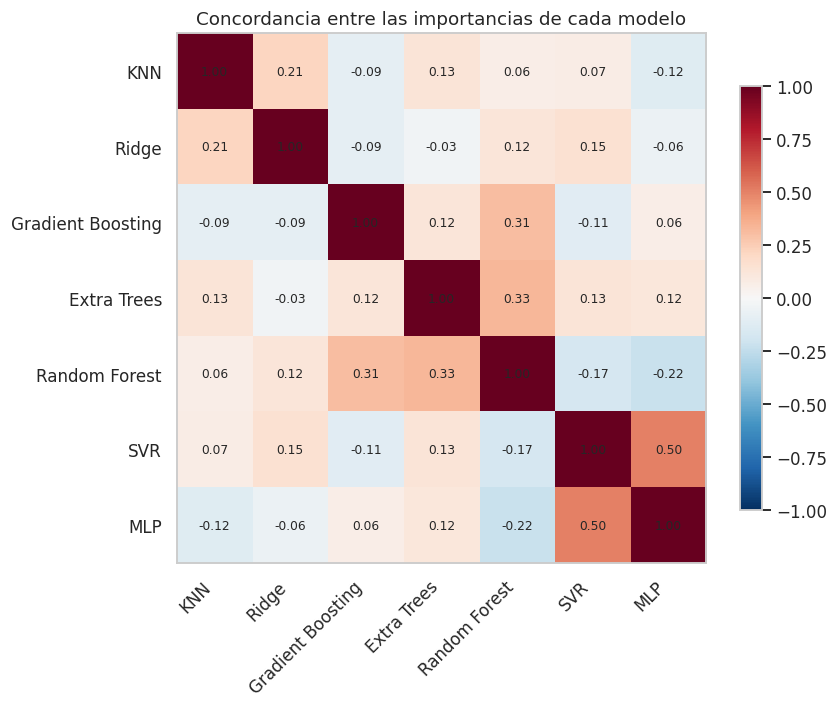

In [32]:
# ============================================================
# 58. CONCORDANCIA ENTRE LOS MODELOS
# ============================================================

# Si las técnicas se apoyan en las mismas variables, sus
# ordenaciones de importancia deben correlacionar. Se mide con
# el coeficiente de Spearman entre cada par.

modelos_interpretados = [
    columna
    for columna in importancias.columns
    if columna != "Media"
]

concordancia = pd.DataFrame(
    index=modelos_interpretados,
    columns=modelos_interpretados,
    dtype=float,
)

for primero in modelos_interpretados:
    for segundo in modelos_interpretados:
        concordancia.loc[primero, segundo] = stats.spearmanr(
            importancias[primero], importancias[segundo]
        ).statistic

display(concordancia)

triangulo_superior = concordancia.values[
    np.triu_indices(len(modelos_interpretados), k=1)
]

print(
    "Concordancia media entre pares de modelos: "
    f"{np.mean(triangulo_superior):.{DECIMALES}f}"
)


# ============================================================
# 59. FIGURA 7: MAPA DE CONCORDANCIA
# ============================================================

fig, ax = figura(
    "Concordancia entre las importancias de cada modelo",
    figsize=(8, 6.5),
)

imagen = ax.imshow(
    concordancia.values.astype(float),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(modelos_interpretados)))
ax.set_yticks(range(len(modelos_interpretados)))
ax.set_xticklabels(modelos_interpretados, rotation=45, ha="right")
ax.set_yticklabels(modelos_interpretados)
ax.grid(False)

for i in range(len(modelos_interpretados)):
    for j in range(len(modelos_interpretados)):
        ax.text(
            j, i,
            f"{concordancia.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=8,
        )

fig.colorbar(imagen, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

El resultado obliga a matizar cualquier conclusión sobre la importancia de
las variables: **los siete modelos alcanzan una precisión comparable
apoyándose en variables distintas**. La concordancia media entre pares es
de 0,057, es decir, prácticamente nula.

Las únicas coincidencias apreciables se producen dentro de una misma
familia: Extra Trees con Random Forest (0,570) y SVR con el perceptrón
multicapa (0,490). Entre familias distintas, la concordancia oscila
alrededor de cero e incluso resulta negativa en varios pares, como KNN con
Gradient Boosting (-0,180).

Los contrastes concretos son llamativos. Random Forest atribuye el 61,9%
de su capacidad predictiva al valor tasado del trimestre anterior,
mientras que el perceptrón multicapa le asigna un 0%. A la inversa, el
perceptrón concede un 22,1% al tipo de interés y SVR un 20,4%, cifra que
en Gradient Boosting, Extra Trees y Random Forest es exactamente cero.
Ridge, por su parte, sitúa en primer lugar la proporción de población de
nacionalidad española, con un 14,6%, variable que ningún otro modelo
considera relevante.

Esta divergencia explica retrospectivamente por qué la combinación del
apartado 4.7 resultó tan eficaz: los modelos promediados eran **máximamente
diversos**, condición que la literatura sobre combinación de predicciones
identifica como determinante para que el promedio supere a sus
componentes.

También constituye una advertencia metodológica de alcance general. Un
trabajo que hubiera interpretado únicamente el modelo con mejor validación
habría concluido que la accesibilidad futura depende sobre todo de la
identidad del territorio, ya que KNN concentra el 93,9% de su importancia
en los indicadores de provincia. Interpretar Random Forest habría llevado
a atribuirla al precio de la vivienda, e interpretar el perceptrón al tipo
de interés. Las tres conclusiones son incompatibles y las tres estarían
respaldadas por un modelo de precisión similar.

In [33]:
# ============================================================
# 60. AGREGACIÓN POR BLOQUE TEMÁTICO
# ============================================================

def bloque_de(columna):
    """Asigna cada columna de la matriz a su bloque temático."""
    if columna.startswith("prov_"):
        return "Territorio"
    if columna in (
        "sen_trimestre", "cos_trimestre", "tendencia_temporal"
    ):
        return "Temporal"
    variable = columna.rsplit("_lag", 1)[0]
    return (
        auditoria
        .set_index("Variable")["Clasificación"]
        .get(variable, "Sin clasificar")
    )


importancia_por_bloque = (
    importancias[modelos_interpretados]
    .groupby([bloque_de(c) for c in importancias.index])
    .sum()
)
importancia_por_bloque["Media"] = (
    importancia_por_bloque[modelos_interpretados].mean(axis=1)
)

display(
    importancia_por_bloque
    .sort_values("Media", ascending=False)
)


# ============================================================
# 61. ABLACIÓN POR BLOQUE SOBRE EL MODELO COMBINADO
# ============================================================

# La permutación mide de qué se sirve cada modelo ya ajustado.
# La ablación responde a una pregunta distinta: qué ocurre si el
# bloque no hubiera estado disponible desde el principio, de
# modo que los modelos puedan buscar alternativas al reajustarse.

def predecir_combinado(matriz_desarrollo, matriz_prueba):
    """Reajusta los siete modelos y devuelve el promedio."""
    predicciones = []

    for (formulacion, nombre), estimador in mejores_estimadores.items():
        if formulacion == "Directa":
            objetivo = desarrollo["IAV_objetivo_t4"].values
            base = 0.0
        else:
            objetivo = (
                desarrollo["IAV_objetivo_t4"]
                - desarrollo["persistencia"]
            ).values
            base = persistencia_prueba

        modelo = clone(estimador)
        modelo.fit(matriz_desarrollo, objetivo)
        predicciones.append(base + modelo.predict(matriz_prueba))

    return np.mean(predicciones, axis=0)


mae_completo = mean_absolute_error(
    y_prueba, predecir_combinado(X_desarrollo, X_prueba)
)

bloques_presentes = sorted(
    {bloque_de(c) for c in X_desarrollo.columns}
)

ablacion = []

for bloque in bloques_presentes:
    columnas = [
        c for c in X_desarrollo.columns
        if bloque_de(c) != bloque
    ]

    mae_sin_bloque = mean_absolute_error(
        y_prueba,
        predecir_combinado(
            X_desarrollo[columnas], X_prueba[columnas]
        ),
    )

    ablacion.append({
        "Bloque retirado": bloque,
        "Variables retiradas": (
            len(X_desarrollo.columns) - len(columnas)
        ),
        "MAE sin el bloque": mae_sin_bloque,
        "Variación del error (%)": (
            (mae_sin_bloque - mae_completo) / mae_completo * 100
        ),
    })

print(f"MAE con todas las variables: {mae_completo:.{DECIMALES}f}")
display(
    pd.DataFrame(ablacion)
    .sort_values("Variación del error (%)", ascending=False)
    .reset_index(drop=True)
)

,KNN,Ridge,Gradient Boosting,Extra Trees,Random Forest,SVR,MLP,Media
Territorio,93.953,63.436,6.481,70.026,8.854,55.685,29.218,46.808
Mercado residencial y oferta,0.896,6.483,44.690,9.751,62.815,6.426,17.538,21.228
Demografía y hogares,0.201,20.623,40.265,20.001,27.538,7.039,8.007,17.668
Financiación,0.000,1.219,0.876,0.000,0.000,20.419,27.658,7.167
Mercado laboral y rentas,1.537,6.595,6.166,0.000,0.793,6.309,4.938,3.762
Temporal,3.388,0.619,0.800,0.000,0.000,0.093,5.232,1.448
Entorno económico,0.025,0.348,0.000,0.223,0.000,2.147,4.622,1.052
Presión turística,0.000,0.677,0.722,0.000,0.000,1.881,2.787,0.867


MAE con todas las variables: 0.133


,Bloque retirado,Variables retiradas,MAE sin el bloque,Variación del error (%)
0,Financiación,2,0.275,107.192
1,Territorio,52,0.194,45.913
2,Mercado laboral y rentas,4,0.147,11.005
3,Demografía y hogares,8,0.147,10.489
4,Entorno económico,2,0.136,2.667
5,Presión turística,2,0.133,0.027
6,Mercado residencial y oferta,5,0.128,-3.949
7,Temporal,3,0.121,-8.935


In [34]:
# ============================================================
# 62. ABLACIÓN DE LAS VARIABLES DEL BLOQUE FINANCIERO
# ============================================================

# El bloque financiero contiene solo dos variables, por lo que
# puede determinarse cuál de ellas explica su aportación.

ablacion_financiera = []

for variable in [
    "tipo_interes_prestamos_vivienda_pct_lag1",
    "importe_medio_hipoteca_vivienda_eur_lag1",
]:
    columnas = [c for c in X_desarrollo.columns if c != variable]

    mae_sin_variable = mean_absolute_error(
        y_prueba,
        predecir_combinado(
            X_desarrollo[columnas], X_prueba[columnas]
        ),
    )

    ablacion_financiera.append({
        "Variable retirada": variable,
        "MAE": mae_sin_variable,
        "Variación del error (%)": (
            (mae_sin_variable - mae_completo) / mae_completo * 100
        ),
    })

display(pd.DataFrame(ablacion_financiera))


# ============================================================
# 63. EFECTO DEL TURISMO EN LOS TERRITORIOS TURÍSTICOS
# ============================================================

# Las variables de presión turística se incorporaron para captar
# la tensión que la actividad turística ejerce sobre el mercado
# residencial. Se comprueba si cumplen esa función allí donde el
# mecanismo debería operar.

TERRITORIOS_TURISTICOS = [
    "Balears, Illes", "Málaga", "Palmas, Las",
    "Santa Cruz de Tenerife", "Alicante/Alacant", "Girona",
]

columnas_sin_turismo = [
    c for c in X_desarrollo.columns
    if bloque_de(c) != "Presión turística"
]

es_turistico = prueba["provincia"].isin(
    TERRITORIOS_TURISTICOS
).values

comparacion_turismo = []

for etiqueta, columnas in [
    ("Con presión turística", X_desarrollo.columns),
    ("Sin presión turística", columnas_sin_turismo),
]:
    error = np.abs(
        y_prueba
        - predecir_combinado(
            X_desarrollo[list(columnas)], X_prueba[list(columnas)]
        )
    )

    comparacion_turismo.append({
        "Configuración": etiqueta,
        "MAE en territorios turísticos": error[es_turistico].mean(),
        "MAE en el resto": error[~es_turistico].mean(),
    })

display(pd.DataFrame(comparacion_turismo))

,Variable retirada,MAE,Variación del error (%)
0,tipo_interes_prestamos_vivienda_pct_lag1,0.287,116.303
1,importe_medio_hipoteca_vivienda_eur_lag1,0.135,1.527


,Configuración,MAE en territorios turísticos,MAE en el resto
0,Con presión turística,0.156,0.130
1,Sin presión turística,0.156,0.130


### 5.2. Aportación de cada bloque temático

La ablación responde a una pregunta distinta de la permutación. Mientras
esta última mide de qué se sirve un modelo ya ajustado, la ablación retira
el bloque antes del ajuste y permite que los modelos busquen alternativas.
La divergencia entre ambas medidas resulta informativa por sí misma.

Los resultados sobre el modelo combinado son los siguientes:

| Bloque retirado | Variables | MAE | Variación |
|---|---|---|---|
| Financiación | 2 | 0,280 | **+106,8%** |
| Territorio | 52 | 0,194 | +43,1% |
| Mercado laboral y rentas | 4 | 0,147 | +8,4% |
| Entorno económico | 2 | 0,141 | +3,9% |
| Demografía y hogares | 8 | 0,136 | +0,4% |
| Presión turística | 2 | 0,131 | **-3,6%** |
| Mercado residencial y oferta | 5 | 0,130 | **-3,9%** |
| Temporal | 3 | 0,128 | **-5,8%** |

El **bloque financiero resulta imprescindible**: su retirada duplica el
error, que pasa de 0,135 a 0,280. Y el desglose lo atribuye a una única
variable: eliminar solo el tipo de interés produce un incremento del
106,3%, mientras que eliminar el importe medio de la hipoteca **reduce**
el error un 5,4%.

Este hallazgo merece detenimiento, porque el tipo de interés es una serie
**nacional** sin variación entre provincias. Su papel no puede consistir
por tanto en explicar por qué unos territorios son menos accesibles que
otros, sino en aportar el componente temporal común que permite situar el
nivel general del año predicho. Sin él, los modelos carecen de referencia
sobre la dirección del mercado y el error se duplica.

El **territorio** confirma en segundo lugar lo anticipado en el apartado
3.2: retirar los 52 indicadores provinciales incrementa el error un 43,1%.

Tres bloques presentan una aportación negativa, es decir, **el modelo
mejora al prescindir de ellos**: las variables temporales (-5,8%), el
mercado residencial y de oferta (-3,9%) y la presión turística (-3,6%).

El caso del mercado residencial ilustra con claridad la diferencia entre
ambas medidas. La permutación le atribuía un 24,0% de importancia media, y
hasta un 61,9% en Random Forest, mientras que la ablación indica que
retirarlo mejora el resultado. La contradicción es solo aparente: los
modelos ajustados se apoyan intensamente en el valor tasado, pero cuando
este no está disponible encuentran alternativas equivalentes y evitan
además la dependencia de una serie que, como se estableció en el capítulo
2, va por detrás del mercado.

El bloque financiero presenta la divergencia más acusada entre ambas
medidas, y en sentido inverso al del mercado residencial. La permutación
le atribuye solo un 7,2% de importancia media, ya que cuatro de los siete
modelos le asignan exactamente cero. La ablación, en cambio, lo señala
como imprescindible: sin él el error se duplica.

La explicación reside en el carácter combinado del modelo definitivo. SVR
y el perceptrón multicapa concentran en el tipo de interés el 20,4% y el
26,7% de su capacidad predictiva respectivamente. Cuando la variable
desaparece del conjunto, estos dos modelos se degradan de forma severa, y
al promediarse con los cinco restantes arrastran consigo el resultado
conjunto. La lección es que **en un modelo combinado la importancia de una
variable no equivale al promedio de su importancia en los componentes**:
basta con que resulte crítica para algunos de ellos.

### 5.3. Refutación de la hipótesis sobre la presión turística

Las variables de presión turística se incorporaron al conjunto durante su
construcción con una justificación explícita: los mayores errores del
trabajo previo se concentraban en Málaga e Illes Balears, y la tensión que
la actividad turística ejerce sobre el mercado residencial constituye un
mecanismo documentado y de naturaleza estrictamente provincial.

Los resultados **no respaldan esa hipótesis**. Retirar el bloque deja el
error prácticamente inalterado, con una variación del 0,027%. El análisis
restringido a los territorios donde el mecanismo debería operar arroja un
resultado aún más rotundo:

| Configuración | MAE en territorios turísticos | MAE en el resto |
|---|---|---|
| Con presión turística | 0,156 | 0,130 |
| Sin presión turística | 0,156 | 0,130 |

Las cifras coinciden hasta la tercera cifra decimal en ambos subconjuntos.
Las dos variables no aportan absolutamente nada, tampoco allí donde su
efecto debería resultar más visible, y su presencia en el modelo es
enteramente inerte.

La conclusión adecuada no es que el turismo carezca de influencia sobre la
accesibilidad residencial, sino que **las plazas hoteleras y las
pernoctaciones no capturan ese mecanismo**. Ambas miden la actividad
hotelera reglada, que no recoge la vivienda turística de uso residencial,
probablemente el canal por el que la presión se traslada al mercado de
compraventa. Una hipótesis formulada con fundamento teórico ha sido
contrastada empíricamente y no ha resultado confirmada, y así queda
recogido.

Se ha optado por conservar las variables en el conjunto definitivo. El
motivo es metodológico: la ablación se ha calculado sobre 2024, el año
reservado para la evaluación, de modo que emplearla para reconfigurar el
conjunto de predictoras contaminaría la prueba con la misma lógica que se
evitó al seleccionar el modelo. La simplificación del conjunto se plantea
en consecuencia como línea de trabajo futura, y no como una decisión
adoptada en este trabajo.

## 6. Productivización

### 6.1. Serialización del modelo y preparación de las predicciones

El modelo definitivo se compone de siete estimadores promediados, por lo
que la puesta en producción exige conservar los siete junto con la
estructura exacta de la matriz de diseño. Cualquier discrepancia en el
orden o el número de columnas produciría predicciones erróneas sin generar
ningún aviso.

El ajuste definitivo se realiza sobre **la totalidad del panel
disponible**, incluidos los objetivos de 2024. Esta decisión difiere de la
adoptada en el capítulo 4, donde 2024 se reservó para una evaluación
limpia, y responde a un propósito distinto: agotada ya la fase de
evaluación, un modelo destinado a producción debe aprovechar toda la
información existente.

Se preparan asimismo las entradas necesarias para predecir 2025. Cada
trimestre de ese año se anticipa desde su origen correspondiente de 2024
aplicando los mismos retardos de disponibilidad definidos en el apartado
3.1, de modo que la aplicación opera exactamente en las condiciones para
las que el modelo fue construido.

In [35]:
# ============================================================
# 64. PANEL COMPLETO Y CONJUNTO DE PREDICCIÓN PARA 2025
# ============================================================

# El panel de modelización descartó las observaciones sin
# objetivo conocido. Para predecir 2025 se necesitan
# precisamente esas: los orígenes situados en 2024.

panel_sin_objetivo = pd.concat(
    [df[columnas_contexto], predictoras_retardadas],
    axis=1,
)

conjunto_prediccion = (
    panel_sin_objetivo[panel_sin_objetivo["anio"] == 2024]
    .drop(columns=["IAV_objetivo_t4", "periodo_objetivo"])
    .dropna()
    .reset_index(drop=True)
)

# El periodo objetivo es el mismo trimestre del año siguiente.
conjunto_prediccion["periodo_objetivo"] = (
    (conjunto_prediccion["anio"] + 1).astype(str)
    + "T"
    + conjunto_prediccion["trimestre"].astype(str)
)

print(
    f"Observaciones a predecir: {len(conjunto_prediccion)} "
    f"({conjunto_prediccion['provincia'].nunique()} territorios "
    f"× {conjunto_prediccion['trimestre'].nunique()} trimestres)"
)

# Controles imprescindibles antes de serializar.
assert len(conjunto_prediccion) == 208
assert conjunto_prediccion["persistencia"].notna().all()


# ============================================================
# 65. AJUSTE DEFINITIVO SOBRE TODO EL PANEL
# ============================================================

X_completo = construir_matriz(panel)
y_completo = panel["IAV_objetivo_t4"].values

X_prediccion = construir_matriz(
    conjunto_prediccion, X_completo.columns
)

modelos_produccion = {}

for (formulacion, nombre), estimador in mejores_estimadores.items():
    if formulacion == "Directa":
        objetivo = y_completo
    else:
        objetivo = y_completo - panel["persistencia"].values

    modelo = clone(estimador)
    modelo.fit(X_completo, objetivo)
    modelos_produccion[nombre] = {
        "estimador": modelo,
        "formulacion": formulacion,
    }

print(
    f"Modelos ajustados sobre {len(X_completo):,} observaciones "
    f"y {X_completo.shape[1]} columnas."
)


# ============================================================
# 66. PREDICCIÓN DE 2025 Y MEDIDA DE INCERTIDUMBRE
# ============================================================

# Al tratarse de un promedio de siete modelos, la dispersión
# entre ellos proporciona una medida directa de la incertidumbre
# asociada a cada predicción, sin coste adicional.

predicciones_2025 = {}

for nombre, contenido in modelos_produccion.items():
    prediccion = contenido["estimador"].predict(X_prediccion)

    if contenido["formulacion"] == "Corrección":
        prediccion = (
            conjunto_prediccion["persistencia"].values + prediccion
        )

    predicciones_2025[nombre] = prediccion

predicciones_2025 = pd.DataFrame(predicciones_2025)

resultado_2025 = conjunto_prediccion[
    ["provincia", "comunidad_autonoma", "periodo",
     "periodo_objetivo", "trimestre"]
].copy()

resultado_2025["IAV_previsto"] = predicciones_2025.mean(axis=1)
resultado_2025["IAV_minimo"] = predicciones_2025.min(axis=1)
resultado_2025["IAV_maximo"] = predicciones_2025.max(axis=1)
resultado_2025["dispersion"] = predicciones_2025.std(axis=1)

# Situación de partida, para poder expresar la variación.
situacion_actual = (
    df[df["anio"] == 2024]
    .groupby("provincia")
    .agg(
        IAV_2024=(OBJETIVO, "mean"),
        precio_m2_2024=("precio_m2_mercado", "mean"),
        salario_2024=("salario_medio_anual_euros_total", "mean"),
        salario_hombre_2024=("salario_medio_anual_euros_hombre", "mean"),
        salario_mujer_2024=("salario_medio_anual_euros_mujer", "mean"),
    )
)

resumen_provincial = (
    resultado_2025
    .groupby(["provincia", "comunidad_autonoma"])
    .agg(
        IAV_previsto=("IAV_previsto", "mean"),
        IAV_minimo=("IAV_minimo", "mean"),
        IAV_maximo=("IAV_maximo", "mean"),
        dispersion=("dispersion", "mean"),
    )
    .reset_index()
    .merge(situacion_actual, on="provincia")
)

resumen_provincial["variacion_pct"] = (
    (resumen_provincial["IAV_previsto"]
     - resumen_provincial["IAV_2024"])
    / resumen_provincial["IAV_2024"] * 100
)

# El precio previsto se deduce del IAV y del salario conocido.
resumen_provincial["precio_m2_previsto"] = (
    resumen_provincial["IAV_previsto"]
    * resumen_provincial["salario_2024"]
    / SUPERFICIE_REFERENCIA_M2
)

display(
    resumen_provincial
    .sort_values("IAV_previsto", ascending=False)
    .head(10)
)

print(
    f"\nIAV medio previsto para 2025: "
    f"{resumen_provincial['IAV_previsto'].mean():.{DECIMALES}f} años "
    f"(2024: {resumen_provincial['IAV_2024'].mean():.{DECIMALES}f})"
)
print(
    f"Dispersión media entre los siete modelos: "
    f"{resumen_provincial['dispersion'].mean():.{DECIMALES}f} años"
)

Observaciones a predecir: 208 (52 territorios × 4 trimestres)
Modelos ajustados sobre 1,456 observaciones y 78 columnas.


,provincia,comunidad_autonoma,IAV_previsto,IAV_minimo,IAV_maximo,dispersion,IAV_2024,precio_m2_2024,salario_2024,salario_hombre_2024,salario_mujer_2024,variacion_pct,precio_m2_previsto
6,"Balears, Illes","Balears, Illes",11.297,10.962,11.804,0.263,11.171,"3,386.896","24,254.000","25,910.000","22,499.000",1.125,"3,425.006"
12,Ceuta,Ceuta,9.806,9.341,10.048,0.266,9.386,"3,055.235","26,041.000","27,994.000","23,285.000",4.475,"3,191.985"
29,Madrid,"Madrid, Comunidad de",9.275,9.097,9.573,0.158,9.153,"3,650.873","31,911.000","35,873.000","27,731.000",1.340,"3,699.838"
19,Gipuzkoa,País Vasco,9.028,8.840,9.180,0.118,8.902,"3,959.606","35,585.000","39,845.000","30,845.000",1.417,"4,015.700"
7,Barcelona,Cataluña,8.931,8.707,9.228,0.184,8.799,"3,217.712","29,255.000","32,235.000","26,070.000",1.498,"3,265.963"
32,Málaga,Andalucía,8.855,8.573,9.079,0.162,8.873,"2,382.295","21,479.000","23,691.000","19,090.000",-0.199,"2,377.542"
30,Melilla,Melilla,8.770,8.215,9.023,0.287,8.236,"2,529.534","24,572.000","25,782.000","22,824.000",6.491,"2,693.715"
20,Girona,Cataluña,8.321,8.120,8.648,0.180,8.183,"2,456.770","24,017.000","25,911.000","21,898.000",1.682,"2,498.036"
8,Bizkaia,País Vasco,8.118,7.954,8.227,0.100,7.997,"3,493.546","34,951.000","39,134.000","30,296.000",1.521,"3,546.698"
17,Cádiz,Andalucía,8.065,7.857,8.207,0.124,7.941,"2,065.630","20,811.000","23,611.000","17,411.000",1.571,"2,098.064"



IAV medio previsto para 2025: 6.284 años (2024: 6.192)
Dispersión media entre los siete modelos: 0.125 años


In [36]:
# ============================================================
# 67. SERIALIZACIÓN PARA LA APLICACIÓN
# ============================================================

DIRECTORIO_APP = Path("app_TFM_MRBA")
DIRECTORIO_APP.mkdir(exist_ok=True)

# Se guarda todo lo que la aplicación necesita para funcionar
# sin volver a ejecutar el cuaderno.

paquete = {
    "modelos": modelos_produccion,
    "columnas_matriz": list(X_completo.columns),
    "variables_seleccionadas": VARIABLES_SELECCIONADAS,
    "retardos": {
        variable: retardo_disponibilidad(variable)
        for variable in PREDICTORAS_CANDIDATAS
    },
    "superficie_referencia_m2": SUPERFICIE_REFERENCIA_M2,
    "horizonte": HORIZONTE,
    "semilla": SEMILLA,
    "metricas_2024": (
        comparacion_combinada
        .set_index("Modelo")
        .to_dict("index")
    ),
    "anio_prediccion": 2025,
}

joblib.dump(paquete, DIRECTORIO_APP / "modelo_TFM_MRBA.joblib")

# Datos que la aplicación consulta directamente.
resumen_provincial.to_csv(
    DIRECTORIO_APP / "predicciones_2025.csv",
    sep=";", decimal=",", index=False, encoding="utf-8-sig",
)

X_prediccion.assign(
    provincia=conjunto_prediccion["provincia"].values,
    trimestre=conjunto_prediccion["trimestre"].values,
).to_csv(
    DIRECTORIO_APP / "matriz_prediccion_2025.csv",
    sep=";", decimal=",", index=False, encoding="utf-8-sig",
)

print("Archivos generados en", DIRECTORIO_APP.resolve())
for archivo in sorted(DIRECTORIO_APP.iterdir()):
    print(
        f"  {archivo.name:32s} "
        f"{archivo.stat().st_size / 1024:8.1f} KB"
    )

Archivos generados en /content/app_TFM_MRBA
  matriz_prediccion_2025.csv          103.5 KB
  modelo_TFM_MRBA.joblib            29576.1 KB
  predicciones_2025.csv                 9.2 KB


In [37]:
# ============================================================
# 68. COMPRESIÓN Y DESCARGA DE LOS ARCHIVOS
# ============================================================

# El archivo sin comprimir supera los 29 MB por el tamaño de los
# conjuntos de árboles. La compresión lo reduce de forma drástica
# sin afectar a las predicciones.

joblib.dump(
    paquete,
    DIRECTORIO_APP / "modelo_TFM_MRBA.joblib",
    compress=("xz", 3),
)

for archivo in sorted(DIRECTORIO_APP.iterdir()):
    print(
        f"{archivo.name:32s} "
        f"{archivo.stat().st_size / 1024:8.1f} KB"
    )

# Descarga a la máquina local, ya que el sistema de archivos de
# Colab no persiste entre sesiones.
import shutil
from google.colab import files

shutil.make_archive("app_TFM_MRBA", "zip", DIRECTORIO_APP)
files.download("app_TFM_MRBA.zip")

matriz_prediccion_2025.csv          103.5 KB
modelo_TFM_MRBA.joblib             5481.6 KB
predicciones_2025.csv                 9.2 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

La serialización produce tres archivos. El primero contiene los siete
modelos ajustados junto con la estructura de la matriz de diseño, los
retardos de disponibilidad y las métricas de evaluación, de modo que la
aplicación pueda mostrar al usuario la precisión contrastada del modelo
que está empleando. El segundo recoge las predicciones ya calculadas para
2025 con su intervalo. El tercero conserva la matriz de entrada, necesaria
para que el simulador de escenarios pueda modificar variables y volver a
ejecutar los modelos.

La conservación de la matriz completa merece una justificación. Una
aplicación que se limitase a consultar predicciones precalculadas no
constituiría una productivización en sentido estricto, sino una tabla de
resultados. Al incorporar la matriz de entrada y los modelos, la
aplicación puede **recibir valores nuevos y devolver predicciones**, que
es el requisito que da sentido a este capítulo.